<div style="border:solid green 2px; padding: 20px">

<b>Комментарий ревьюера:</b>

Привет, Илья! Меня зовут Алина Соловьева, я буду проверять твой проект.

Предлагаю общаться на «ты» — если удобнее на «вы», просто скажи об этом в первом ответе. Отвечай, пожалуйста, прямо под моими комментариями — так проще уследить за всеми правками. Если что-то в замечании непонятно, не стесняйся спрашивать, разберёмся вместе. Пожалуйста, не удаляй мои комментарии — они понадобятся на следующей итерации проверки.

Цветовая разметка комментариев:

<div class="alert alert-success">
<b>Комментарий ревьюера:</b>☀️
Так отмечены сильные стороны работы — то, что уже получилось хорошо и стоит сохранить.
</div>

<div class="alert alert-warning">
<b>Комментарий ревьюера:</b>⛅️
Так отмечены необязательные улучшения — они не блокируют принятие проекта, но сделают его лучше.
</div>

<div class="alert alert-danger">
<b>Комментарий ревьюера:</b>☁️
Так отмечены обязательные исправления — без них проект пока не может быть принят.
</div>

Если захочешь ответить прямо в тетрадке — оформи реплику похожим блоком, синим:

<div class="alert alert-info">
<b>Комментарий студента:</b>
Так можно оформить свой ответ или вопрос — просто скопируй эту разметку под нужный комментарий и впиши текст.
</div>

Работа читается как готовое исследование: единый план во введении, аккуратная предобработка с проверками после каждого шага и рекомендация, собранная из нескольких независимых срезов данных

</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Привет, Алина! Спасибо за подробное ревью, на «ты» удобно. Твои комментарии не трогал, свои ответы оставил синими блоками сразу под каждым.

Что поправил во второй версии:

1. Заглушка `unknown` теперь ставится только в `market`, а не во все текстовые столбцы, и её роль оговорена отдельно.
2. Проверку середины интервала переделал: считаю исходные даты, выпадающие за свой интервал. Нашлось 658 таких строк, все пересчитаны.
3. Сравнение месяцев 2014 и 2013 приведено в соответствие с графиком, фраза про начало декабря исправлена.
4. Графики объёма и популярности типов финансирования переведены на единый словарь цветов.
5. Вывод про 2014 год сужен: снижение медианы прекратилось, а про число сделок судить рано.
6. SaaS и Design больше не названы растущими без спада, добавлен подсчёт лет со снижением и график в двух шкалах.
7. Итоговая рекомендация переписана под эти же уточнения.

Из-за пересчёта дат среднего раунда часть цифр изменилась: итоговая выборка 35 589 компаний, растущих сегментов стало 13, обновилась динамика по годам. Все числа в выводах пересчитаны заново.

</div>

# Проект. Исследование стартапов

## Введение

**Автор:** Илья Погодин  
**Дата:** 08.09.2026

### О чём проект

Инвестиционная компания думает выйти на рынок стартапов: покупать компании и развивать их. Прежде чем вкладывать деньги, она хочет разобраться, как этот рынок устроен. Кто получает финансирование, в каких объёмах, какими инструментами и сколько из вложенного возвращается инвесторам.

Для ответа у нас есть выгрузка Crunchbase по компаниям и отдельная таблица с возвратами средств по годам.

### Что нужно получить

Главный результат - ответ на вопрос заказчика: если бы сейчас был 2015 год, в какую отрасль и каким типом финансирования стоило бы заходить.

Чтобы к нему прийти, разберём данные по шагам:

1. Загрузим таблицы, оценим качество данных и приведём их в рабочий вид: столбцы, типы, дубликаты, пропуски.
2. Разделим компании на группы по сроку финансирования и сравним группы между собой.
3. Разнесём сегменты рынка на массовые, средние и нишевые.
4. Найдём типичные и аномальные суммы финансирования, уберём выбросы и ограничим период годами, по которым данных достаточно.
5. Сравним типы финансирования по объёму, популярности и возвратам.
6. Посмотрим, как менялись размер раунда и активность рынка по годам и какие сегменты росли.
7. Посчитаем, какая доля вложений возвращается и у каких инструментов это устойчиво.
8. Соберём выводы и рекомендации.

### Данные

- `cb_investments` - компании и полученное финансирование: название, отрасль (`market`), сумма привлечённых средств (`funding_total_usd`), число раундов и участников, даты основания и раундов, суммы по 13 типам финансирования и по раундам `round_A`-`round_H`.
- `cb_returns` - сколько денег вернулось инвесторам по годам и типам финансирования, в миллионах долларов.

<div class="alert alert-success" id="review-p0-intro">
<b>Комментарий ревьюера:</b>☀️
Введение отвечает на вопросы заказчика

Введение сразу закрывает три вещи: зачем этот анализ бизнесу, какие данные под рукой и в каком порядке пойдёт работа. План из восьми шагов дальше действительно соблюдается, поэтому по тетрадке легко идти и без подсказок
</div>

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета - `cb_investments.zip`. Внутри архива один файл - `cb_investments.csv`.

Описание данных:
* `name` - название компании.
* `homepage_url` - ссылка на сайт компании.
* `category_list` - категории, в которых работает компания. Указываются через `|`.
* `market` - основной рынок или отрасль компании.
* `funding_total_usd` - общий объём привлечённых инвестиций в долларах США.
* `status` - текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` - код страны, например USA.
* `state_code` - код штата или региона, например, CA.
* `region` - регион, например, SF Bay Area.
* `city` - город, в котором расположена компания.
* `funding_rounds` - общее число раундов финансирования.
* `participants` - число участников в раундах финансирования.
* `founded_at` - дата основания компании.
* `founded_month` - месяц основания в формате `YYYY-MM`.
* `founded_quarter` - квартал основания в формате `YYYY-QN`.
* `founded_year` - год основания.
* `first_funding_at` - дата первого финансирования.
* `mid_funding_at` - дата среднего по времени раунда финансирования.
* `last_funding_at` - дата последнего финансирования.
* `seed` - сумма инвестиций на посевной стадии.
* `venture` - сумма венчурных инвестиций.
* `equity_crowdfunding` - сумма, привлечённая через долевой краудфандинг.
* `undisclosed` - сумма финансирования нераскрытого типа.
* `convertible_note` - сумма инвестиций через конвертируемые займы.
* `debt_financing` - сумма долгового финансирования.
* `angel` - сумма инвестиций от бизнес-ангелов.
* `grant` - сумма полученных грантов.
* `private_equity` - сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` - сумма финансирования после IPO.
* `post_ipo_debt` - сумма долгового финансирования после IPO.
* `secondary_market` - сумма сделок на вторичном рынке.
* `product_crowdfunding` - сумма, привлечённая через продуктовый краудфандинг.
* `round_A` - `round_H` - сумма инвестиций в соответствующем раунде.

Название дополнительного датасета - `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` - год возврата средств.
* `seed` - сумма возвратов от посевных инвестиций.
* `venture` - сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` - сумма, возвращённая по долевому краудфандингу.
* `undisclosed` - сумма возвратов нераскрытого типа.
* `convertible_note` - сумма возвратов через конвертируемые займы.
* `debt_financing` - сумма возвратов от долгового финансирования.
* `angel` - сумма возвратов бизнес-ангелам.
* `grant` - сумма возвратов по грантам.
* `private_equity` - сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` - сумма возвратов от IPO.
* `post_ipo_debt` - сумма возвратов от долгового IPO.
* `secondary_market` - сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` - сумма возвратов по продуктовому краудфандингу.

Файлы находятся в папке `datasets`, если вы выполняете работу на платформе. В случае, если вы делаете работу локально, доступ к файлам в папке можно получить по адресу `https://code.s3.yandex.net/datasets/` + имя файла.

### 1.1. Вывод общей информации

Загрузите необходимые для работы библиотеки.

Совет: если вы неоднократно используете какой-либо код, вынесите его в начало проекта в виде функций.

In [1]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

%matplotlib inline

# настройки отображения таблиц
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# единый стиль оформления графиков
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titleweight'] = 'bold'

# единая палитра для групп по срокам финансирования - используется на всех графиках проекта
GROUP_COLORS = {
    'Единичное финансирование': '#2a7f83',
    'Срок финансирования до года': '#7fb069',
    'Срок финансирования более года': '#d1743f'
}

# единая палитра для типов финансирования: цвет закреплён за типом,
# чтобы графики объёма и популярности можно было сравнивать между собой

# типы финансирования - понадобятся во многих расчётах
FUNDING_TYPES = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
                 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
                 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']

TYPE_COLORS = dict(zip(FUNDING_TYPES, sns.color_palette('tab20', len(FUNDING_TYPES))))

<div class="alert alert-success" id="review-p0-imports">
<b>Комментарий ревьюера:</b>☀️
Настройки и общие константы вынесены в начало

Импорты, настройки отображения и общие константы собраны в одном месте в начале работы. Палитра групп и список типов финансирования дальше переиспользуются, поэтому цвета и состав категорий не разъезжаются между разными графиками
</div>

In [2]:
# вспомогательные функции, которые используются в проекте несколько раз

def overview(data, title, n=5):
    """Краткая сводка по датафрейму: размер, типы, первые строки."""
    print('=== %s ===' % title)
    print('Размер: %d строк, %d столбцов' % data.shape)
    data.info()
    display(data.head(n))


def missing_report(data, title='Пропуски'):
    """Таблица пропусков: количество и доля по столбцам."""
    report = pd.DataFrame({'пропусков': data.isna().sum(),
                           'доля, %': (data.isna().mean() * 100).round(1)})
    report = report[report['пропусков'] > 0].sort_values('пропусков', ascending=False)
    print(title)
    display(report if len(report) else 'пропусков нет')


def iqr_outliers(series):
    """Флаг выброса по правилу 1.5 IQR (для использования внутри groupby.transform)."""
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)


def money(x, pos=None):
    """Формат денежных подписей на осях: 1.2B, 340M, 15K."""
    for div, suffix in [(1e9, 'B'), (1e6, 'M'), (1e3, 'K')]:
        if abs(x) >= div:
            return '%.4g%s' % (x / div, suffix)
    return '%.0f' % x


MONEY_FMT = mticker.FuncFormatter(money)

<div class="alert alert-success" id="review-p0-helpers">
<b>Комментарий ревьюера:</b>☀️
Повторяющийся код вынесен в функции

Повторяющиеся куски вынесены в функции overview, missing_report и iqr_outliers. Сводка по таблицам благодаря этому собирается одинаково, а правило полутора межквартильных размахов описано один раз и дальше не переписывается заново
</div>

Загрузите все данные по проекту.

Совет: данные из zip-архива можно загрузить следующим кодом:

`df = pd.read_csv("https://code.s3.yandex.net/datasets/cb_investments.zip", sep=';', low_memory=False)`

In [3]:
# основной датасет с компаниями и финансированием
INVEST_URL = 'https://code.s3.yandex.net/datasets/cb_investments.zip'

try:
    investments = pd.read_csv(INVEST_URL, sep=';', low_memory=False)
    print('cb_investments загружен по ссылке')
except Exception as e:
    investments = pd.read_csv('cb_investments.csv', sep=';', low_memory=False)
    print('cb_investments загружен локально')

print('Размер:', investments.shape)

cb_investments загружен по ссылке
Размер: (54294, 40)


<div class="alert alert-success" id="review-p0-loading">
<b>Комментарий ревьюера:</b>☀️
Обе таблицы загружены и размеры проверены

Обе таблицы загружаются штатным способом, с запасным путём на случай локального запуска, и размер каждой сразу выводится. Дальше видно, что именно прочиталось, а не приходится верить на слово
</div>

In [4]:
# дополнительный датасет с возвратами средств
for path in ['/datasets/cb_returns.csv',
             'https://code.s3.yandex.net/datasets/cb_returns.csv',
             'cb_returns.csv']:
    try:
        returns = pd.read_csv(path)
        print('cb_returns загружен:', path)
        break
    except Exception:
        continue

print('Размер:', returns.shape)

cb_returns загружен: /datasets/cb_returns.csv
Размер: (15, 14)


Выведите информацию, которая необходима для принятия решений о предобработке.

In [5]:
# общая информация по таблице с компаниями
overview(investments, 'cb_investments')

=== cb_investments ===
Размер: 54294 строк, 40 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarte

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,1.00,NaN,1636-09-08,NaN,NaN,1636.00,2014-01-06,NaN,2014-01-06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,90000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,1.00,NaN,1785-01-01,NaN,NaN,1785.00,2014-05-15,NaN,2014-05-15,0.00,2000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,1.00,1.00,1802-07-19,NaN,NaN,1802.00,2009-07-02,2009-07-02,2009-07-02,0.00,9000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,3.00,0.00,1817-01-01,NaN,NaN,1817.00,2013-11-21,2013-11-21,2014-11-03,0.00,0.00,0.00,1600000.00,0.00,0.00,0.00,6100000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,1.00,NaN,1826-01-01,NaN,NaN,1826.00,2014-01-14,NaN,2014-01-14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,540000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [6]:
# описательная статистика по числовым столбцам
display(investments.describe().T[['count', 'mean', 'min', '50%', 'max']])

# отдельно смотрим на проблемные столбцы: их названия содержат лишние пробелы,
# а суммы финансирования записаны текстом с разделителями разрядов
print('Названия столбцов «как есть»:', [c for c in investments.columns[:6]])
print()
print('Примеры значений funding_total_usd:')
print(investments[' funding_total_usd '].dropna().head(5).tolist())
print()
print('Примеры значений market:')
print(investments[' market '].dropna().unique()[:5].tolist())
print('Уникальных значений market:', investments[' market '].nunique())
print()
print('Самые ранние даты основания:', sorted(investments['founded_at'].dropna().unique())[:3])

# заглядываем вперёд: каким станет разброс сумм после приведения столбца к числу
peek = pd.to_numeric(investments[' funding_total_usd '].astype(str).str.strip().str.replace(',', '', regex=False),
                     errors='coerce')
print('Разброс сумм финансирования: от %.0f до %.0f' % (peek.min(), peek.max()))

,count,mean,min,50%,max
funding_rounds,49438.00,1.70,1.00,1.00,18.00
participants,30473.00,1.45,0.00,1.00,36.00
founded_year,38554.00,2007.09,1636.00,2010.00,2014.00
seed,49438.00,217321.50,0.00,0.00,130000000.00
venture,49438.00,7501050.54,0.00,0.00,2351000000.00
equity_crowdfunding,49438.00,6163.32,0.00,0.00,25000000.00
undisclosed,49438.00,130221.28,0.00,0.00,292432833.00
convertible_note,49438.00,23364.10,0.00,0.00,300000000.00
debt_financing,49438.00,1888156.89,0.00,0.00,30079503000.00
angel,49438.00,65418.98,0.00,0.00,63590263.00


Названия столбцов «как есть»: ['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status']

Примеры значений funding_total_usd:
[' 9,00,00,000 ', ' 20,00,000 ', ' 90,00,000 ', ' 77,00,000 ', ' 5,40,000 ']

Примеры значений market:
[' Education ', ' Business Services ', ' Social Media ', ' Hardware + Software ', ' Biotechnology ']
Уникальных значений market: 939

Самые ранние даты основания: ['1636-09-08', '1785-01-01', '1802-07-19']
Разброс сумм финансирования: от 1 до 30079503000


In [7]:
# общая информация по таблице с возвратами
overview(returns, 'cb_returns', n=15)

=== cb_returns ===
Размер: 15 строк, 14 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
me

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.00,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.00,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.00,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.00,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.00,203.70,76.76,0.00,0.12,0.02


In [8]:
# пропуски и дубликаты
missing_report(investments, 'Пропуски в cb_investments:')
missing_report(returns, 'Пропуски в cb_returns:')

print('Полных дубликатов строк: cb_investments =', investments.duplicated().sum(),
      '| cb_returns =', returns.duplicated().sum())
print('Строк, где вообще нет данных (все значения пропущены):',
      investments.isna().all(axis=1).sum())
print('Строк с прочерком вместо суммы финансирования:',
      (investments[' funding_total_usd '].astype(str).str.strip() == '-').sum())

Пропуски в cb_investments:


,пропусков,"доля, %"
state_code,24133,44.40
mid_funding_at,24006,44.20
participants,23821,43.90
founded_month,15812,29.10
founded_quarter,15812,29.10
founded_at,15740,29.00
founded_year,15740,29.00
city,10972,20.20
country_code,10129,18.70
region,10129,18.70


Пропуски в cb_returns:


'пропусков нет'

Полных дубликатов строк: cb_investments = 4855 | cb_returns = 0
Строк, где вообще нет данных (все значения пропущены): 4856
Строк с прочерком вместо суммы финансирования: 8531


<div class="alert alert-success" id="review-p0-diagnostics">
<b>Комментарий ревьюера:</b>☀️
Пропуски и дубликаты проверены до чистки

Перед предобработкой видно всё, что нужно для решений: доля пропусков по каждому столбцу, число полных дубликатов и отдельно посчитанные прочерки вместо суммы финансирования. Именно из этой картины дальше вырастают шаги чистки, и это правильный порядок
</div>

Сделайте вывод о полученных данных: каков их объём, соответствуют ли данные описанию, есть ли пропущенные значения, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.

**Вывод о полученных данных.**

В `cb_investments` 54 294 строки и 40 столбцов, в `cb_returns` - 15 строк и 14 столбцов, по одной на каждый год с 2000 по 2014. Состав столбцов совпадает с описанием данных, ничего лишнего или недостающего нет.

С типами повезло меньше:

- `funding_total_usd` лежит текстом. Суммы записаны с разделителями разрядов вида ` 9,00,00,000 `, а у 8 531 компании вместо суммы стоит прочерк.
- Все четыре столбца с датами тоже текстовые.
- `funding_rounds` и `founded_year` стали вещественными из-за пропусков, хотя это счётчики.

Пропусков много, и распределены они неравномерно: `state_code` - 44,4 %, `mid_funding_at` - 44,2 %, `participants` - 43,9 %, дата и год основания - 29,0 %, `country_code` и `region` - 18,7 %, `market` и `category_list` - 16,2 %. Отдельно бросаются в глаза 4 856 строк (8,9 %), где не заполнено вообще ничего.

На что ещё обратить внимание при предобработке:

1. Названия столбцов оформлены небрежно: ` market ` и ` funding_total_usd ` с пробелами по краям, раунды в верхнем регистре (`round_A`).
2. Пробелы есть и в самих значениях, из-за чего ` Education ` и ` Education` считаются разными сегментами. Уникальных значений `market` сейчас 939, и это явно завышено.
3. 4 855 полных дубликатов - те самые пустые строки, которые повторяют друг друга.
4. Прочерк в сумме финансирования - не обычный пропуск: у таких компаний нули по всем типам финансирования. Раунды были, а сумм в базе нет.
5. Среди дат основания встречается 1636-09-08, то есть XVII век. В датах раундов тоже попадаются записи с испорченным годом, при переводе в дату они не распознаются.
6. Разброс сумм огромный: от 1 доллара до 30 млрд. Распределение придётся смотреть в логарифмическом масштабе, а выбросы искать по каждому сегменту отдельно.
7. Единицы измерения в таблицах разные: в `cb_investments` доллары, в `cb_returns` миллионы долларов.

<div class="alert alert-success" id="review-p0-first-conclusion">
<b>Комментарий ревьюера:</b>☀️
Вывод о качестве данных подтверждается расчётами

Вывод собран строго по посчитанным числам: объём таблиц, доли пропусков, дубликаты, разброс сумм и разные единицы измерения в двух таблицах. Хорошо и то, что прочерк в сумме финансирования назван не обычным пропуском, а особым состоянием, и что список проблем дальше действительно разбирается по пунктам
</div>

### 1.2. Предобработка данных

Проверьте названия столбцов в датасетах: все ли они точно отражают содержимое данных и оформлены в удобном для работы стиле. При необходимости приведите их к единому аккуратному стилю.

In [9]:
# приводим названия столбцов к единому стилю: без лишних пробелов, в нижнем регистре
df = investments.copy()

print('Было: ', [c for c in df.columns[:6]])
df.columns = df.columns.str.strip().str.lower()
print('Стало:', [c for c in df.columns[:6]])

returns.columns = returns.columns.str.strip().str.lower()

print()
print('Столбцы раундов после приведения:', [c for c in df.columns if c.startswith('round_')])
print('Столбцы cb_returns:', list(returns.columns))

Было:  ['name', 'homepage_url', 'category_list', ' market ', ' funding_total_usd ', 'status']
Стало: ['name', 'homepage_url', 'category_list', 'market', 'funding_total_usd', 'status']

Столбцы раундов после приведения: ['round_a', 'round_b', 'round_c', 'round_d', 'round_e', 'round_f', 'round_g', 'round_h']
Столбцы cb_returns: ['year', 'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding']


<div class="alert alert-success" id="review-p0-columns">
<b>Комментарий ревьюера:</b>☀️
Названия столбцов приведены к единому стилю

Названия столбцов приведены к единому виду сразу в обеих таблицах, без краевых пробелов и в нижнем регистре, а результат тут же показан. Дальше по коду не приходится помнить, где стоял лишний пробел
</div>

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [10]:
# суммы записаны текстом с разделителями разрядов, а часть значений заменена прочерком
na_before = df['funding_total_usd'].isna().sum()

df['funding_total_usd'] = pd.to_numeric(
    df['funding_total_usd'].astype(str).str.strip().str.replace(',', '', regex=False),
    errors='coerce')

print('Тип столбца:', df['funding_total_usd'].dtype)
print('Пропусков было %d, стало %d - прочерки «-» превратились в пропуски' %
      (na_before, df['funding_total_usd'].isna().sum()))
print('Отрицательных и нулевых значений:', int((df['funding_total_usd'] <= 0).sum()))
display(df['funding_total_usd'].describe().to_frame('funding_total_usd'))

Тип столбца: float64
Пропусков было 4856, стало 13387 - прочерки «-» превратились в пропуски
Отрицательных и нулевых значений: 0


,funding_total_usd
count,40907.00
mean,15912526.05
std,168678800.17
min,1.00
25%,350000.00
50%,2000000.00
75%,10000000.00
max,30079503000.00


<div class="alert alert-success" id="review-p0-funding-numeric">
<b>Комментарий ревьюера:</b>☀️
Сумма финансирования переведена в число без потерь

Перевод суммы финансирования в число сделан аккуратно: разделители разрядов убраны, а прочерки превращаются в пропуски, а не в нули. Разница между отсутствием измерения и настоящим нулём здесь сохранена, и это как раз то место, где её легко потерять
</div>

Обработайте типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

In [11]:
# столбцы с датами хранятся текстом - переводим в datetime
date_cols = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']

for col in date_cols:
    converted = pd.to_datetime(df[col], errors='coerce')
    broken = df.loc[converted.isna() & df[col].notna(), col]
    print('%-18s не распознано дат: %-3d примеры: %s' % (col, len(broken), list(broken.unique()[:3])))
    df[col] = converted

# год основания логичнее хранить целым числом (тип Int64 допускает пропуски)
df['founded_year'] = df['founded_year'].astype('Int64')

print()
print('Проверка корректности: раундов, где последняя дата раньше первой:',
      int((df['last_funding_at'] < df['first_funding_at']).sum()))
print('Компаний, основанных позже первого раунда финансирования:',
      int((df['founded_at'] > df['first_funding_at']).sum()))
print()
print('Диапазоны дат после преобразования:')
display(df[date_cols].agg(['min', 'max']).T)

founded_at         не распознано дат: 1   примеры: ['1636-09-08']
first_funding_at   не распознано дат: 10  примеры: ['0011-11-14', '0019-11-20', '0020-06-14']
mid_funding_at     не распознано дат: 0   примеры: []
last_funding_at    не распознано дат: 6   примеры: ['0001-05-14', '0201-01-01', '0001-07-14']

Проверка корректности: раундов, где последняя дата раньше первой: 0
Компаний, основанных позже первого раунда финансирования: 2739

Диапазоны дат после преобразования:


,min,max
founded_at,1785-01-01,2014-12-13
first_funding_at,1921-09-01,2014-12-31
mid_funding_at,1960-01-01,2013-12-12
last_funding_at,1921-09-01,2015-01-01


<div class="alert alert-success" id="review-p0-dates">
<b>Комментарий ревьюера:</b>☀️
Даты переведены устойчиво к испорченным годам

Перевод дат сделан устойчиво: испорченные годы вроде 0011 или 0201 не ломают выполнение и не превращаются в правдоподобную современную дату, а их количество выведено по каждому столбцу. Плюс сразу проверено, что последняя дата раунда не оказывается раньше первой
</div>

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [12]:
# в таблице возвратов год - это идентификатор строки, делаем его индексом
if returns.index.name != 'year':
    returns = returns.set_index('year')

print('Индекс:', returns.index.name, '| период:', returns.index.min(), '-', returns.index.max())
display(returns.head())

Индекс: year | период: 2000 - 2014


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.00,0.00,0.94,0.00,0.20,0.00
2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.00,0.00,0.46,0.00,0.46,0.00
2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.00,1.51,0.34,0.00,0.06,0.00
2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.00,1.62,2.11,0.00,0.08,0.00
2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.00,2.19,3.38,0.00,0.55,0.00


<div class="alert alert-success" id="review-p0-returns-index">
<b>Комментарий ревьюера:</b>☀️
Год стал индексом таблицы возвратов

Год в таблице возвратов сделан индексом, и период с 2000 по 2014 сразу проверен выводом. Дальше выравнивание годовых агрегатов по этому индексу пойдёт без ручной подгонки
</div>

Обработайте текстовые данные, если это необходимо. Пропуски в текстовых столбцах заполните заглушками там, где это понадобится.

In [13]:
# в текстовых столбцах встречаются лишние пробелы по краям - из-за них
# один и тот же сегмент рынка выглядит как несколько разных
text_cols = df.select_dtypes(include='object').columns.tolist()
print('Текстовые столбцы:', text_cols)

market_before = df['market'].nunique()
for col in text_cols:
    df[col] = df[col].str.strip()
print('Уникальных значений market: было %d, стало %d' % (market_before, df['market'].nunique()))

# заглушку ставим точечно, а не во все текстовые столбцы подряд.
# market - единственный текстовый признак, по которому дальше идёт группировка:
# без заглушки компании без отрасли молча выпали бы из всех расчётов по сегментам
df['market'] = df['market'].fillna('unknown')
print('Компаний без указанной отрасли (метка unknown):', (df['market'] == 'unknown').sum())

# в остальных текстовых столбцах пропуски оставляем как есть: по ним ничего не группируется,
# а лишняя категория unknown только маскировала бы отсутствие данных
other_text = [c for c in text_cols if c != 'market']
print()
print('Пропуски в остальных текстовых столбцах оставлены без изменений:')
display(df[other_text].isna().sum().to_frame('пропусков'))

Текстовые столбцы: ['name', 'homepage_url', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city', 'founded_month', 'founded_quarter']
Уникальных значений market: было 939, стало 439
Компаний без указанной отрасли (метка unknown): 8817

Пропуски в остальных текстовых столбцах оставлены без изменений:


,пропусков
name,4857
homepage_url,8305
category_list,8817
status,6170
country_code,10129
state_code,24133
region,10129
city,10972
founded_month,15812
founded_quarter,15812


<div class="alert alert-success" id="review-p0-market-strip">
<b>Комментарий ревьюера:</b>☀️
Пробелы в значениях убраны, сегменты перестали дробиться

Пробелы убраны не только в заголовках, но и в самих значениях, и это здесь ключевой шаг: число уникальных рынков падает с 939 до 439, то есть один и тот же сегмент перестаёт считаться несколькими разными. Без этого и сегментация, и поиск выбросов считались бы по кускам одного сегмента
</div>

<div class="alert alert-warning" id="review-p0-unknown-stub">
<b>Комментарий ревьюера:</b>⛅️
Заглушка unknown ставится во все текстовые столбцы, включая market

Заглушку unknown получают все текстовые столбцы подряд, а среди них market, по которому дальше строится вся сегментация рынка. Компании без известной отрасли становятся обычным сегментом наравне с настоящими и могут всплыть в ответах про сегменты с наибольшей долей аномалий или про рост в последнем году. Заглушки полезнее ставить точечно, там, где столбец реально используется дальше, а по market отдельно проговорить, остаётся ли он в анализе сегментов и как это учитывается в выводах
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Согласен, заглушку во все столбцы подряд ставить не стоило. Теперь `unknown` подставляется только в `market` - это единственный текстовый признак, по которому дальше идёт группировка, и без заглушки 2 503 компании без отрасли молча выпали бы из расчётов по сегментам. В остальных текстовых столбцах пропуски оставил как есть.

Про судьбу `market` проговорил отдельно в промежуточном выводе: `unknown` - это не отрасль, а признак незаполненной карточки. В рейтинг сегментов по доле аномалий эта группа больше не попадает (её показатель вывожу отдельно, справочно), из динамики массовых сегментов в разделе 4.2 она исключена, а в выбросах участвует наравне с остальными, иначе эти компании просто остались бы без проверки.

</div>

Обработайте полные дубликаты в данных и пропуски в `funding_total_usd`. избавьтесь от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [14]:
# 1) полные дубликаты строк
rows_start = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after_dupes = len(df)
print('Удалено полных дубликатов: %d' % (rows_start - after_dupes))

# 2) строки без данных о финансировании: у них пропущен общий объём инвестиций,
# а суммы по всем типам финансирования равны нулю - анализировать в них нечего
no_money = df['funding_total_usd'].isna()
print('Строк без данных о финансировании: %d' % no_money.sum())
print('Суммарное финансирование по типам в этих строках: %.0f' %
      df.loc[no_money, FUNDING_TYPES].sum().sum())

df = df.dropna(subset=['funding_total_usd']).reset_index(drop=True)
print()
print('Строк было %d, стало %d - отброшено %d (%.1f%%)' %
      (rows_start, len(df), rows_start - len(df), (rows_start - len(df)) / rows_start * 100))

Удалено полных дубликатов: 4855
Строк без данных о финансировании: 8532
Суммарное финансирование по типам в этих строках: 0

Строк было 54294, стало 40907 - отброшено 13387 (24.7%)


<div class="alert alert-success" id="review-p0-dupes">
<b>Комментарий ревьюера:</b>☀️
Дубликаты и строки без финансирования обработаны с проверкой

Дубликаты и строки без данных о финансировании удалены отдельными шагами, и перед удалением проверено, что суммы по всем типам финансирования там действительно нулевые. Потери сразу посчитаны и в строках, и в процентах, так что решение видно вместе с его ценой
</div>

Заполните пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмите приблизительно середину интервала между этими двумя датами.

Оцените размер оставшихся пропусков в столбце.

In [15]:
# середину интервала финансирования восстанавливаем из первой и последней дат раунда
gaps_before = df['mid_funding_at'].isna().sum()

middle_date = df['first_funding_at'] + (df['last_funding_at'] - df['first_funding_at']) / 2
df['mid_funding_at'] = df['mid_funding_at'].fillna(middle_date)

gaps_after = df['mid_funding_at'].isna().sum()
print('Пропусков в mid_funding_at: было %d (%.1f%%), заполнено %d, осталось %d (%.2f%%)' %
      (gaps_before, gaps_before / len(df) * 100, gaps_before - gaps_after,
       gaps_after, gaps_after / len(df) * 100))

# проверять восстановленные даты бессмысленно: середина интервала по построению лежит внутри него.
# Смысл есть в обратной проверке - сколько ИСХОДНЫХ дат выпадает за собственный интервал
outside = (df['mid_funding_at'].notna()
           & ~df['mid_funding_at'].between(df['first_funding_at'], df['last_funding_at']))

print()
print('Исходных дат вне интервала между первым и последним раундом: %d (%.1f%% от заполненных)' %
      (outside.sum(), outside.sum() / df['mid_funding_at'].notna().sum() * 100))
print('   раньше первого раунда: %d, позже последнего: %d' %
      ((df.loc[outside, 'mid_funding_at'] < df.loc[outside, 'first_funding_at']).sum(),
       (df.loc[outside, 'mid_funding_at'] > df.loc[outside, 'last_funding_at']).sum()))
print('   из них у компаний с единственным раундом: %d' %
      (df.loc[outside, 'funding_rounds'] == 1).sum())
display(df.loc[outside, ['name', 'first_funding_at', 'mid_funding_at', 'last_funding_at', 'funding_rounds']].head())

# такие даты противоречат сами себе, поэтому пересчитываем их по тому же правилу
df.loc[outside, 'mid_funding_at'] = middle_date[outside]

still_outside = (df['mid_funding_at'].notna()
                 & ~df['mid_funding_at'].between(df['first_funding_at'], df['last_funding_at'])).sum()
print()
print('После пересчёта дат вне интервала осталось:', still_outside)
display(df[['first_funding_at', 'mid_funding_at', 'last_funding_at']].head())

Пропусков в mid_funding_at: было 13676 (33.4%), заполнено 13675, осталось 1 (0.00%)

Исходных дат вне интервала между первым и последним раундом: 658 (1.6% от заполненных)
   раньше первого раунда: 546, позже последнего: 111
   из них у компаний с единственным раундом: 391


,name,first_funding_at,mid_funding_at,last_funding_at,funding_rounds
152,Remedi SeniorCare,2009-07-21,2013-08-07,2011-08-07,2.00
352,Pathology Holdings,2009-10-20,2011-12-05,2009-10-20,1.00
518,MEMC Electronic Materials,2009-12-04,2009-11-20,2009-12-04,1.00
584,Motionsoft,2010-09-03,2010-08-31,2014-10-15,5.00
653,3D Systems,2014-01-15,2010-01-13,2014-10-13,3.00



После пересчёта дат вне интервала осталось: 0


,first_funding_at,mid_funding_at,last_funding_at
0,2014-01-06,2014-01-06,2014-01-06
1,2014-05-15,2014-05-15,2014-05-15
2,2009-07-02,2009-07-02,2009-07-02
3,2013-11-21,2013-11-21,2014-11-03
4,2014-01-14,2014-01-14,2014-01-14


<div class="alert alert-success" id="review-p0-mid-funding">
<b>Комментарий ревьюера:</b>☀️
Середина интервала восстановлена корректно, остаток измерен

Пропуски в mid_funding_at заполнены именно серединой между первым и последним раундом, как того требует задание, и остаток измерен: незаполненной осталась одна строка, для которой середину посчитать не из чего. Придуманных дат там, где интервала нет, не появилось
</div>

Оцените полноту данных и сделайте предварительный вывод о том, достаточно ли данных для решения задач проекта. Какой процент данных был отброшен?

In [16]:
# сколько данных осталось и где ещё есть пропуски
missing_report(df, 'Пропуски после предобработки:')

print('Исходный размер данных: %d строк' % len(investments))
print('Осталось после предобработки: %d строк' % len(df))
print('Отброшено: %d строк (%.1f%%)' %
      (len(investments) - len(df), (len(investments) - len(df)) / len(investments) * 100))

Пропуски после предобработки:


,пропусков,"доля, %"
state_code,15288,37.40
participants,13576,33.20
founded_month,8772,21.40
founded_quarter,8772,21.40
founded_at,8707,21.30
founded_year,8706,21.30
city,4505,11.00
country_code,3819,9.30
region,3819,9.30
category_list,2503,6.10


Исходный размер данных: 54294 строк
Осталось после предобработки: 40907 строк
Отброшено: 13387 строк (24.7%)


<div class="alert alert-success" id="review-p0-loss">
<b>Комментарий ревьюера:</b>☀️
Потеря данных посчитана от исходного размера

Потеря данных посчитана от исходного размера и показана рядом с тем, какие пропуски остались после чистки. Видно и сколько ушло, и чего именно не хватает в оставшемся наборе
</div>

In [17]:
# итоговый вид данных, с которыми будем работать дальше
overview(df, 'Данные после предобработки', n=3)

=== Данные после предобработки ===
Размер: 40907 строк, 40 столбцов
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40907 entries, 0 to 40906
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40906 non-null  object        
 1   homepage_url          38593 non-null  object        
 2   category_list         38404 non-null  object        
 3   market                40907 non-null  object        
 4   funding_total_usd     40907 non-null  float64       
 5   status                39802 non-null  object        
 6   country_code          37088 non-null  object        
 7   state_code            25619 non-null  object        
 8   region                37088 non-null  object        
 9   city                  36402 non-null  object        
 10  funding_rounds        40907 non-null  float64       
 11  participants          27331 non-null  float64       
 12  founde

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,participants,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,Harvard University,http://harvard.edu,|Education|,Education,90000000.00,operating,USA,MA,Boston,Cambridge,1.00,NaN,NaT,NaN,NaN,1636,2014-01-06,2014-01-06,2014-01-06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,90000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,University of New Brunswick,http://www.unb.ca,NaN,unknown,2000000.00,operating,NaN,NaN,NaN,NaN,1.00,NaN,1785-01-01,NaN,NaN,1785,2014-05-15,2014-05-15,2014-05-15,0.00,2000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,9000000.00,operating,USA,DE,"Wilmington, Delaware",Wilmington,1.00,1.00,1802-07-19,NaN,NaN,1802,2009-07-02,2009-07-02,2009-07-02,0.00,9000000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


### Промежуточный вывод

**Что сделали.** Убрали пробелы из названий столбцов и привели их к нижнему регистру. `funding_total_usd` перевели в число: сняли разделители разрядов, прочерки стали пропусками. Четыре столбца с датами перевели в `datetime`, год основания - в целочисленный тип. В `cb_returns` год стал индексом. В текстовых столбцах обрезали пробелы по краям, и только это сократило число уникальных сегментов с 939 до 439. Даты с испорченным годом вида «0011-11-14» не распознались и стали пропусками: 10 в `first_funding_at`, 6 в `last_funding_at` и 1 в `founded_at`.

**Заглушку поставили только в market.** Это единственный текстовый признак, по которому дальше идёт группировка: без заглушки 2 503 компании без указанной отрасли молча выпали бы из всех расчётов по сегментам. В остальных текстовых столбцах пропуски оставили как есть - по ним ничего не группируется, а лишняя категория `unknown` только маскировала бы отсутствие данных. При этом `unknown` - не отрасль, а признак незаполненной карточки, поэтому в отраслевых рейтингах и в динамике сегментов эта группа не участвует.

**Корректность значений.** Отрицательных и нулевых сумм нет, минимум - 1 доллар. Порядок дат не нарушен: ни одной компании, у которой последний раунд датирован раньше первого. Единственная нестыковка - 2 739 компаний с датой основания позже первого раунда финансирования. Это ошибка заполнения карточек, но дата основания в расчётах не участвует, так что на выводы она не влияет.

**Сколько потеряли.** Удалили 4 855 полных дубликатов и 8 532 строки без данных о финансировании: у них нет ни общей суммы, ни сумм по типам, анализировать там нечего. Вместе это 13 387 строк, или 24,7 % выгрузки. Осталось 40 907 компаний. Цифра выглядит большой, но выбросили мы только мусор.

**Даты среднего раунда.** В `mid_funding_at` было 13 676 пропусков (33,4 %), и появляются они у компаний с одним раундом, где никакой средней даты просто не существует. Заполнили серединой интервала между первым и последним раундом, незаполненной осталась одна строка.

Проверять восстановленные значения бессмысленно: середина интервала по построению лежит внутри него. Полезнее обратная проверка - сколько исходных дат выпадает за собственный интервал. Таких нашлось **658, это 1,6 % заполненных**: 546 датированы раньше первого раунда, 111 позже последнего, а 391 из них принадлежит компаниям с единственным раундом, где средней даты быть не может в принципе. Испорченными датами это не объясняется, их после очистки остались единицы. Такие значения противоречат сами себе, поэтому мы пересчитали их по тому же правилу - серединой интервала. После пересчёта дат вне интервала не осталось.

**Хватит ли данных.** Хватит. Всё, что нужно проекту - суммы, число раундов, даты раундов, типы финансирования и сегмент рынка - заполнено полностью. Оставшиеся пропуски приходятся на второстепенные поля: `participants` (33,2 %), дата и год основания (21,3 %). 40 907 компаний и история раундов до конца 2014 года - этого достаточно.

<div class="alert alert-warning" id="review-F-034">
<b>Комментарий ревьюера:</b>⛅️
Проверка середины интервала подтверждает не то, что заявлено

Проверка попадания середины между первым и последним раундом устроена так, что восстановленные даты проходят её всегда: середина по построению лежит внутри интервала. Подтверждает она поэтому не качество восстановления, а кое-что другое: строки, которые проверку не прошли, это исходные значения `mid_funding_at`, выпадающие за собственный интервал финансирования. Испорченными датами их не объяснить, таких после очистки осталась всего пара, так что стоит посчитать эти строки отдельно и решить, что с ними делать
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Замечание в точку, проверка была тавтологичной: середина интервала по построению всегда внутри него, так что она ничего не подтверждала.

Переделал её в обратную сторону - теперь считаю, сколько исходных дат выпадает за собственный интервал. Таких оказалось 658, это 1,6 % заполненных: 546 датированы раньше первого раунда, 111 позже последнего, а 391 принадлежит компаниям с единственным раундом, где средней даты быть не может в принципе. Испорченными датами это не объясняется, их после очистки остались единицы.

Решил считать такие значения ошибочными и пересчитать по тому же правилу - серединой интервала. После пересчёта дат вне интервала не осталось. Это повлияло на дальнейшие расчёты: часть компаний переехала в другие годы, поэтому динамика по годам и список растущих сегментов немного изменились, все числа в выводах пересчитаны.

</div>

## Шаг 2. Инжиниринг признаков

При выполнении заданий не забывайте интерпретировать полученные результаты и делать промежуточные выводы.

### 2.1. Группы по срокам финансирования

Разделите все компании на три группы:

* Единичное финансирование - был всего один раунд финансирования.

* Срок финансирования до года - между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируйте соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

Совет: Для ясности и согласованности используйте единую цветовую палитру для всех графиков, чтобы каждая категория (например, «Единичное финансирование») всегда отображалась одним цветом.

In [18]:
# делим компании на три группы по сроку финансирования
funding_days = (df['last_funding_at'] - df['first_funding_at']).dt.days

df['funding_group'] = np.where(
    df['funding_rounds'] == 1, 'Единичное финансирование',
    np.where(funding_days <= 365, 'Срок финансирования до года', 'Срок финансирования более года'))

# у части компаний с несколькими раундами даты повреждены - срок посчитать нельзя,
# поэтому в группы их не относим, чтобы не завышать искусственно последнюю группу
unknown_period = funding_days.isna() & (df['funding_rounds'] > 1)
df.loc[unknown_period, 'funding_group'] = np.nan
print('Компаний без корректных дат раундов (в группы не вошли):', unknown_period.sum())

# проверяем границы групп
print('Максимальный срок в группе «до года», дней:',
      funding_days[df['funding_group'] == 'Срок финансирования до года'].max())
print('Минимальный срок в группе «более года», дней:',
      funding_days[df['funding_group'] == 'Срок финансирования более года'].min())

groups = df.groupby('funding_group').agg(компаний=('name', 'size'),
                                         объём=('funding_total_usd', 'sum'))
groups['доля компаний, %'] = (groups['компаний'] / groups['компаний'].sum() * 100).round(1)
groups['доля инвестиций, %'] = (groups['объём'] / groups['объём'].sum() * 100).round(1)
groups['объём, млрд $'] = (groups['объём'] / 1e9).round(1)
groups['средний чек, млн $'] = (groups['объём'] / groups['компаний'] / 1e6).round(2)

display(groups[['компаний', 'доля компаний, %', 'объём, млрд $', 'доля инвестиций, %', 'средний чек, млн $']])
print('Медианная длительность финансирования у компаний с несколькими раундами: %.0f дней'
      % funding_days[df['funding_rounds'] > 1].median())

Компаний без корректных дат раундов (в группы не вошли): 2
Максимальный срок в группе «до года», дней: 365.0
Минимальный срок в группе «более года», дней: 366.0


,компаний,"доля компаний, %","объём, млрд $","доля инвестиций, %","средний чек, млн $"
funding_group,,,,,
Единичное финансирование,24113,58.90,199.30,30.60,8.27
Срок финансирования более года,12291,30.00,402.70,61.90,32.76
Срок финансирования до года,4501,11.00,48.90,7.50,10.86


Медианная длительность финансирования у компаний с несколькими раундами: 684 дней


<div class="alert alert-success" id="review-F-038">
<b>Комментарий ревьюера:</b>☀️
Группы по срокам собраны строго по постановке

Единичное финансирование отобрано по числу раундов, а не по нулевому интервалу дат, поэтому компании с несколькими раундами в один день туда по ошибке не попали. Границу видно прямо в печати: максимум в группе до года и минимум в следующей отличаются ровно на день. Отдельно понравилось, что две компании с нечитаемыми датами раундов не отправлены в группу более года, а вынесены из разбиения и посчитаны
</div>

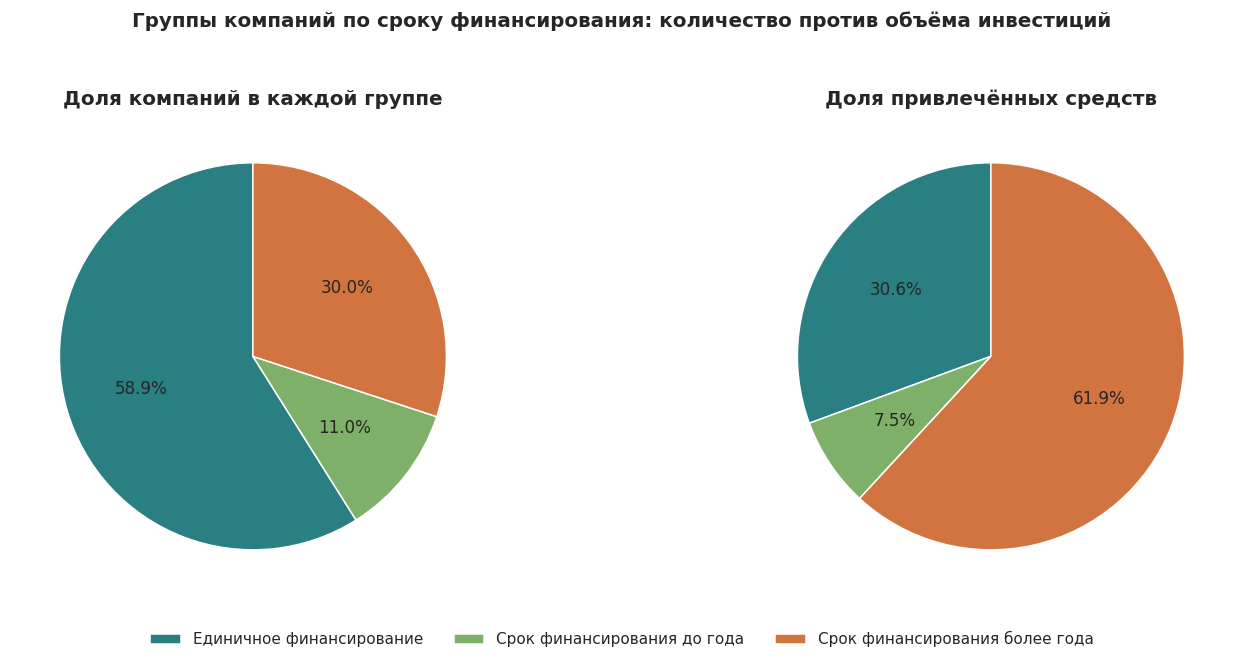

In [19]:
# соотношение групп по количеству компаний и по объёму инвестиций
order = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
plot_df = groups.loc[order]
colors = [GROUP_COLORS[g] for g in order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(plot_df['компаний'], labels=None, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 11})
axes[0].set_title('Доля компаний в каждой группе')

axes[1].pie(plot_df['объём'], labels=None, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white'}, textprops={'fontsize': 11})
axes[1].set_title('Доля привлечённых средств')

fig.legend(order, loc='lower center', ncol=3, frameon=False, fontsize=10)
fig.suptitle('Группы компаний по сроку финансирования: количество против объёма инвестиций',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

**Вывод по разделу 2.1.** Компании и деньги распределились по группам противоположным образом.

| Группа | Компаний | Доля компаний | Объём | Доля инвестиций | Средний чек |
|---|---|---|---|---|---|
| Единичное финансирование | 24 113 | 58,9 % | 199,3 млрд долл. | 30,6 % | 8,3 млн долл. |
| Срок финансирования до года | 4 501 | 11,0 % | 48,9 млрд долл. | 7,5 % | 10,9 млн долл. |
| Срок финансирования более года | 12 291 | 30,0 % | 402,7 млрд долл. | 61,9 % | 32,8 млн долл. |

Почти шесть компаний из десяти получили деньги ровно один раз, и на них приходится меньше трети всех инвестиций. У тех, кто финансировался дольше года, всё наоборот: 30,0 % рынка по числу компаний и 61,9 % по деньгам, а средний чек выше в четыре раза.

Группа «до года» самая малочисленная (11,0 %) и по объёму почти незаметна (7,5 %). Медианный разрыв между первым и последним раундом у компаний с несколькими раундами - 684 дня, почти два года. То есть типичная история финансирования растянута во времени, а не собрана из быстрых сделок подряд.

Ещё две компании с несколькими раундами в группы не попали: у них повреждены даты раундов, посчитать срок невозможно.

Для инвестора отсюда следует простое: деньги в этом рынке идут к компаниям, которые проходят несколько раундов за несколько лет. Разовое финансирование - массовая, но мелкая история.

<div class="alert alert-success" id="review-F-040">
<b>Комментарий ревьюера:</b>☀️
Вывод по группам согласован с расчётом

Доли по числу компаний и по деньгам сверены с таблицей и сходятся, а сам разворот сюжета сформулирован по делу: массовая часть рынка получает разовые небольшие суммы, а основной объём уходит тем, кто проходит несколько раундов. Медианный разрыв почти в два года здесь хорошо подпирает мысль о растянутых во времени историях финансирования
</div>

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитайте, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесите к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесите к средним, а сегменты до 35 компаний отнесите к нишевым. Рассчитайте, сколько сегментов попадает в каждую из категорий.

Постройте график распределения количества компаний в сегментах и отобразите на нём разделение на нишевые и средние сегменты.

Всего сегментов в данных: 395


,сегментов,компаний,"доля компаний, %"
массовые (более 120),49,36236,88.60
средние (35-120),57,3841,9.40
нишевые (менее 35),289,830,2.00


Топ-10 сегментов по числу компаний:


,компаний
Software,4812
Biotechnology,3590
unknown,2503
Mobile,2344
E-Commerce,1866
Curated Web,1693
Enterprise Software,1381
Health Care,1185
Clean Technology,1180
Games,1117


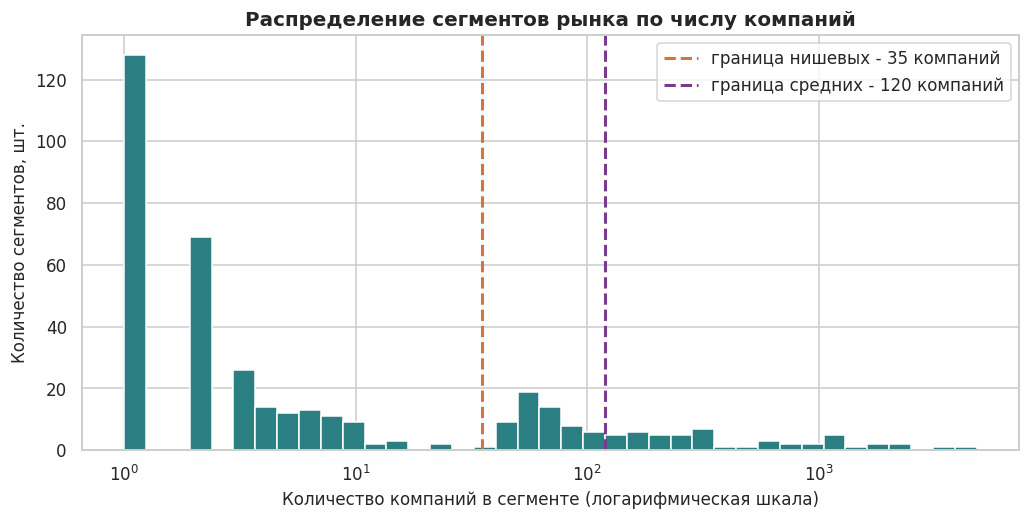

In [20]:
# как часто встречается каждый сегмент рынка
market_counts = df['market'].value_counts()
print('Всего сегментов в данных:', len(market_counts))

mass_segments = market_counts[market_counts > 120]
mid_segments = market_counts[(market_counts >= 35) & (market_counts <= 120)]
niche_segments = market_counts[market_counts < 35]

summary = pd.DataFrame({
    'сегментов': [len(mass_segments), len(mid_segments), len(niche_segments)],
    'компаний': [mass_segments.sum(), mid_segments.sum(), niche_segments.sum()]
}, index=['массовые (более 120)', 'средние (35-120)', 'нишевые (менее 35)'])
summary['доля компаний, %'] = (summary['компаний'] / len(df) * 100).round(1)
display(summary)

print('Топ-10 сегментов по числу компаний:')
display(market_counts.head(10).to_frame('компаний'))

fig, ax = plt.subplots(figsize=(11, 5))
bins = np.logspace(0, np.log10(market_counts.max()), 40)
ax.hist(market_counts.values, bins=bins, color='#2a7f83', edgecolor='white')
ax.axvline(35, color='#d1743f', linestyle='--', linewidth=2, label='граница нишевых - 35 компаний')
ax.axvline(120, color='#7a3b8f', linestyle='--', linewidth=2, label='граница средних - 120 компаний')
ax.set_xscale('log')
ax.set_title('Распределение сегментов рынка по числу компаний')
ax.set_xlabel('Количество компаний в сегменте (логарифмическая шкала)')
ax.set_ylabel('Количество сегментов, шт.')
ax.legend()
plt.show()

<div class="alert alert-success" id="review-F-043">
<b>Комментарий ревьюера:</b>☀️
Пороги сегментов разнесены по заданию, распределение читается

Пороги 35 и 120 разнесены ровно так, как просит задание, вместе с включающей верхней границей средних. Гистограмма в логарифмическом масштабе с двумя вертикальными границами читается сразу: видно и длинный хвост из мелких сегментов, и то, где проходит разделение
</div>

Оставьте в столбце `market` только массовые сегменты. Для остальных сегментов замените значения на заглушки - `niche` для нишевых и `mid` для средних.

Дальнейшие исследования выполняйте с учётом этой замены. Индивидуальные сегменты внутри средней и нишевой групп рассматривать не нужно - они объединяются в два общих сегмента.


In [21]:
# оставляем в market только массовые сегменты, остальные заменяем заглушками
mass_names = set(mass_segments.index) - {'unknown'}
mid_names = set(mid_segments.index)

def to_segment(market):
    if market in mass_names:
        return market
    if market in mid_names:
        return 'mid'
    if market == 'unknown':
        return 'unknown'
    return 'niche'

df['market'] = df['market'].apply(to_segment)

print('Значений в market после замены:', df['market'].nunique(),
      '(из них массовых сегментов: %d)' % len(mass_names))
display(df['market'].value_counts().head(8).to_frame('компаний'))
print('Компаний в заглушках: mid - %d, niche - %d, unknown - %d' %
      ((df['market'] == 'mid').sum(), (df['market'] == 'niche').sum(), (df['market'] == 'unknown').sum()))

Значений в market после замены: 51 (из них массовых сегментов: 48)


,компаний
Software,4812
mid,3841
Biotechnology,3590
unknown,2503
Mobile,2344
E-Commerce,1866
Curated Web,1693
Enterprise Software,1381


Компаний в заглушках: mid - 3841, niche - 830, unknown - 2503


<div class="alert alert-success" id="review-F-045">
<b>Комментарий ревьюера:</b>☀️
Укрупнение сегментов выполнено и используется дальше

Укрупнение сделано аккуратно: массовые сегменты остались под своими именами, средние и нишевые свернулись в `mid` и `niche`, и весь дальнейший расчёт идёт уже по укрупнённому столбцу. Полезно, что пропуск сегмента не подмешан к настоящим отраслям, а остался самостоятельным значением: иначе он вошёл бы в массовые третьим по величине
</div>

**Вывод по разделу 2.2.** Всего в данных 395 сегментов, и компании распределены по ним очень неровно.

| Категория | Сегментов | Компаний | Доля компаний |
|---|---|---|---|
| массовые (более 120 компаний) | 49 | 36 236 | 88,6 % |
| средние (35-120) | 57 | 3 841 | 9,4 % |
| нишевые (менее 35) | 289 | 830 | 2,0 % |

289 сегментов из 395 - нишевые, но в них всего 2,0 % компаний. При этом 49 массовых сегментов собирают почти 90 % рынка. Самые крупные - Software (4 812 компаний), Biotechnology (3 590), Mobile (2 344), E-Commerce (1 866), Curated Web (1 693).

Средние и нишевые сегменты свернули в заглушки `mid` и `niche`: по отдельности в них слишком мало компаний, чтобы делать выводы, а вместе получаются две нормальные группы для сравнения.

Заглушка `unknown` - это 2 503 компании, у которых сегмент не указан. По числу компаний она проходит порог массового сегмента, но отраслью не является, поэтому в отраслевом анализе я её отдельно не рассматриваю. Итого в `market` осталось 51 значение: 48 массовых сегментов и три заглушки.

<div class="alert alert-success" id="review-F-046">
<b>Комментарий ревьюера:</b>☀️
Вывод по сегментации назван вслух вместе с решением про пропуски

Числа в выводе сходятся с таблицей, а решение про `unknown` проговорено и обосновано: заглушка проходит порог по числу компаний, но отраслью не служит. Такое проговаривание заметно облегчает чтение работы дальше, потому что читателю сразу понятно, почему в списке массовых сегментов их 48, а не 49
</div>

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оцените, какой размер общего финансирования для одной компании будет типичным, а какой - выбивающимся. Укажите интервал, в котором лежат типичные значения.

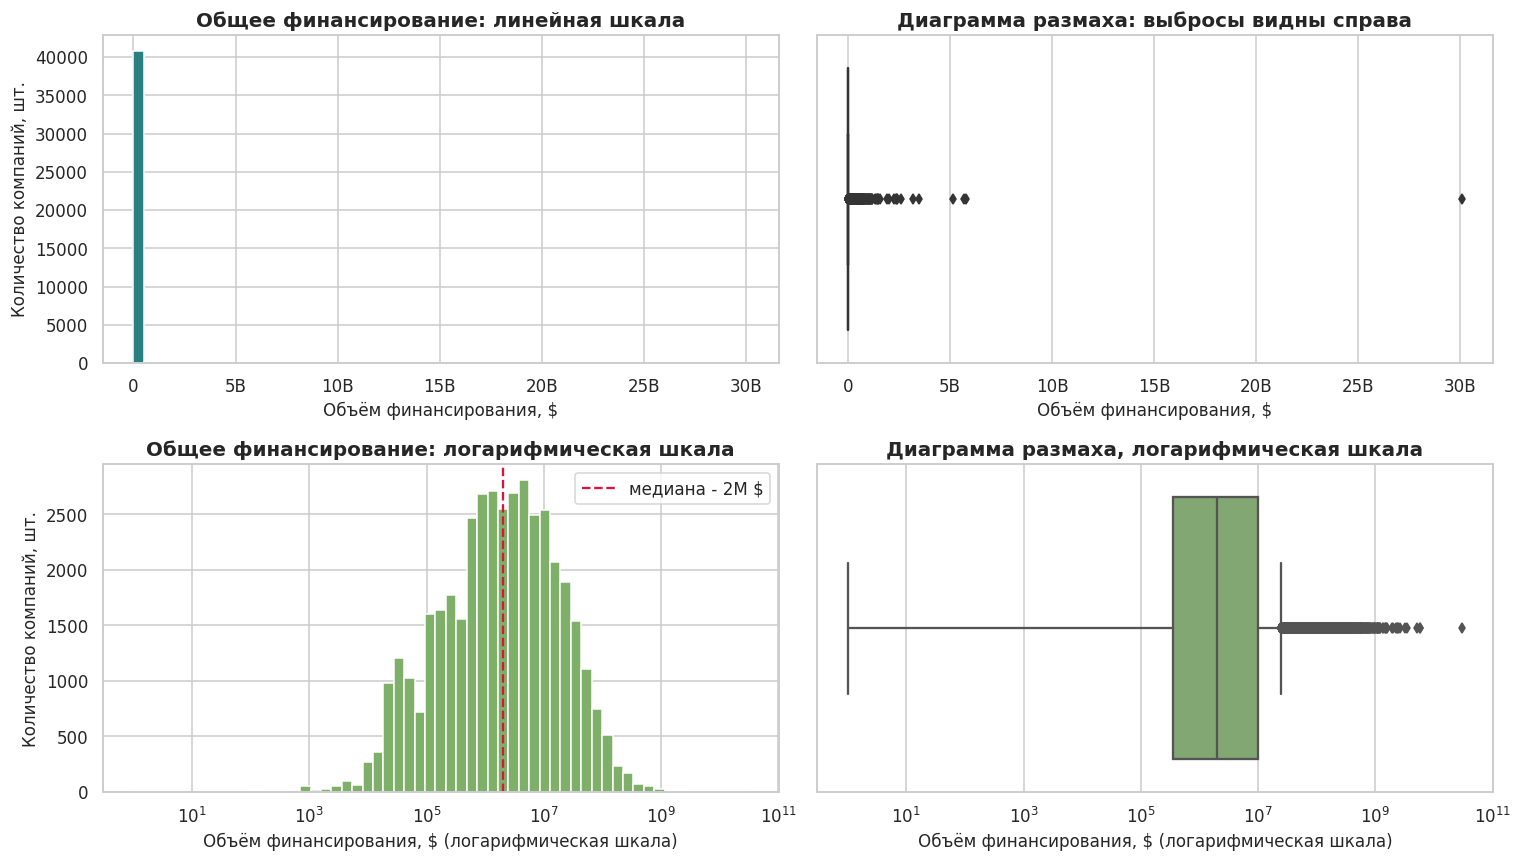

In [22]:
# распределение общего объёма финансирования: сильно скошено, поэтому смотрим и в
# обычном, и в логарифмическом масштабе
total = df['funding_total_usd']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(total, bins=60, color='#2a7f83')
axes[0, 0].set_title('Общее финансирование: линейная шкала')
axes[0, 0].set_xlabel('Объём финансирования, $')
axes[0, 0].set_ylabel('Количество компаний, шт.')
axes[0, 0].xaxis.set_major_formatter(MONEY_FMT)

sns.boxplot(x=total, color='#2a7f83', ax=axes[0, 1])
axes[0, 1].set_title('Диаграмма размаха: выбросы видны справа')
axes[0, 1].set_xlabel('Объём финансирования, $')
axes[0, 1].xaxis.set_major_formatter(MONEY_FMT)

log_bins = np.logspace(np.log10(total.min()), np.log10(total.max()), 60)
axes[1, 0].hist(total, bins=log_bins, color='#7fb069')
axes[1, 0].set_xscale('log')
axes[1, 0].axvline(total.median(), color='crimson', linestyle='--',
                   label='медиана - %s $' % money(total.median()))
axes[1, 0].set_title('Общее финансирование: логарифмическая шкала')
axes[1, 0].set_xlabel('Объём финансирования, $ (логарифмическая шкала)')
axes[1, 0].set_ylabel('Количество компаний, шт.')
axes[1, 0].legend()

sns.boxplot(x=total, color='#7fb069', ax=axes[1, 1])
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('Диаграмма размаха, логарифмическая шкала')
axes[1, 1].set_xlabel('Объём финансирования, $ (логарифмическая шкала)')

plt.tight_layout()
plt.show()

<div class="alert alert-success" id="review-F-049">
<b>Комментарий ревьюера:</b>☀️
Масштаб оси выбран осознанно и объяснён

Логарифмическая шкала здесь по делу, а не для красоты: в линейном масштабе гистограмма схлопывается в один столбик у нуля, и это видно на соседней панели. Подписи осей называют и саму величину, и её масштаб, поэтому график читается без дополнительных пояснений
</div>

In [23]:
# числовые границы типичных значений
q1, q3 = total.quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr

print('Медиана: %s $' % money(total.median()))
print('Типичный интервал (между 1-м и 3-м квартилями): от %s до %s $' % (money(q1), money(q3)))
print('В этот интервал попадает %.1f%% компаний' % (total.between(q1, q3).mean() * 100))
print('Верхняя граница «усов» по правилу 1.5 IQR: %s $ - её превышают %.1f%% компаний' %
      (money(upper), (total > upper).mean() * 100))
print()
display(total.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_frame('funding_total_usd'))

Медиана: 2M $
Типичный интервал (между 1-м и 3-м квартилями): от 350K до 10M $
В этот интервал попадает 51.3% компаний
Верхняя граница «усов» по правилу 1.5 IQR: 24.48M $ - её превышают 12.8% компаний



,funding_total_usd
count,40907.00
mean,15912526.05
std,168678800.17
min,1.00
10%,59596.00
25%,350000.00
50%,2000000.00
75%,10000000.00
90%,31536108.80
99%,200000000.00


Определите компании с аномальным объёмом общего финансирования - используйте метод IQR отдельно по каждому сегменту. Напомним, что все нишевые сегменты должны быть объединены в одну группу, а средние - в другую.

Определите сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведите топ таких сегментов.

In [24]:
# выбросы ищем отдельно внутри каждого сегмента: в разных отраслях
# нормальный размер финансирования разный
df['is_outlier'] = df.groupby('market')['funding_total_usd'].transform(iqr_outliers)

print('Компаний с аномальным объёмом финансирования: %d (%.1f%% от всех)' %
      (df['is_outlier'].sum(), df['is_outlier'].mean() * 100))
print('На них приходится %.1f%% всех привлечённых средств' %
      (df.loc[df['is_outlier'], 'funding_total_usd'].sum() / df['funding_total_usd'].sum() * 100))
print()
print('Границы нормального финансирования в нескольких крупных сегментах:')
bounds = (df[df['market'].isin(['Software', 'Biotechnology', 'Mobile', 'E-Commerce', 'mid', 'niche'])]
          .groupby('market')['funding_total_usd']
          .agg(компаний='size', q1=lambda s: s.quantile(0.25), медиана='median',
               q3=lambda s: s.quantile(0.75)))
bounds['верхняя граница'] = bounds['q3'] + 1.5 * (bounds['q3'] - bounds['q1'])
display(bounds.applymap(lambda v: money(v) if v > 1000 else v))

Компаний с аномальным объёмом финансирования: 5244 (12.8% от всех)
На них приходится 75.2% всех привлечённых средств

Границы нормального финансирования в нескольких крупных сегментах:


,компаний,q1,медиана,q3,верхняя граница
market,,,,,
Biotechnology,3.59K,1.5M,5.508M,22.03M,52.83M
E-Commerce,1.866K,226.6K,1.25M,6.458M,15.8M
Mobile,2.344K,300K,1.7M,7.694M,18.79M
Software,4.812K,500K,2.2M,8.5M,20.5M
mid,3.841K,250K,1.5M,7.85M,19.25M
niche,830,150K,972.5K,5.388M,13.24M


<div class="alert alert-success" id="review-F-052">
<b>Комментарий ревьюера:</b>☀️
Выбросы посчитаны отдельно по каждому укрупнённому сегменту

Выбросы ищутся внутри каждого укрупнённого сегмента, и именно это здесь принципиально: нормальный чек в биотехнологиях и в мобильных приложениях отличается в разы, а единый порог по всему рынку записал бы в аномалии обычные для отрасли сделки. Таблица с границами по нескольким крупным сегментам хорошо показывает, насколько они разъезжаются
</div>

,компаний,аномальных,"доля аномальных, %"
market,,,
Real Estate,279,48,17.20
Entertainment,150,25,16.70
Consulting,349,58,16.60
Search,291,48,16.50
Cloud Computing,152,25,16.40
Photography,204,33,16.20
SaaS,272,44,16.20
Technology,238,38,16.00
Video,188,30,16.00


Для справки, компании без указанной отрасли:


,компаний,аномальных,"доля аномальных, %"
market,,,
unknown,2503,373,14.90


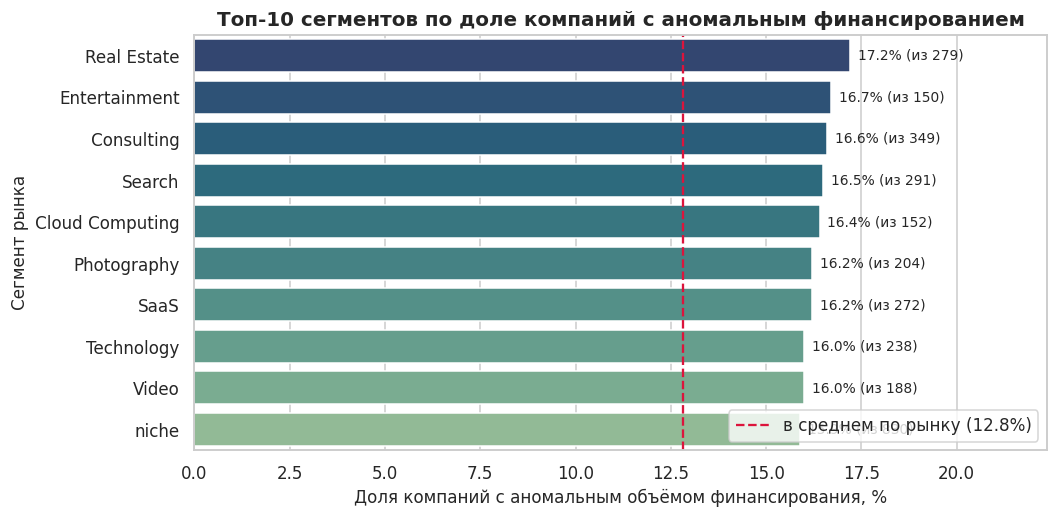

In [25]:
# сегменты с наибольшей долей компаний, получивших аномальное финансирование
outlier_share = df.groupby('market')['is_outlier'].agg(компаний='size', аномальных='sum')
outlier_share['доля аномальных, %'] = (outlier_share['аномальных'] / outlier_share['компаний'] * 100).round(1)
# unknown - не сегмент рынка, а метка незаполненной карточки, в рейтинг отраслей он не идёт
ranking = outlier_share.drop(index='unknown', errors='ignore')
top_outliers = ranking.sort_values('доля аномальных, %', ascending=False).head(10)
display(top_outliers)

print('Для справки, компании без указанной отрасли:')
display(outlier_share.loc[['unknown']])

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_outliers['доля аномальных, %'].values,
            y=list(top_outliers.index), palette='crest_r', ax=ax)
for i, (v, n) in enumerate(zip(top_outliers['доля аномальных, %'], top_outliers['компаний'])):
    ax.text(v + 0.2, i, '%.1f%% (из %d)' % (v, n), va='center', fontsize=9)
ax.axvline(df['is_outlier'].mean() * 100, color='crimson', linestyle='--',
           label='в среднем по рынку (%.1f%%)' % (df['is_outlier'].mean() * 100))
ax.set_title('Топ-10 сегментов по доле компаний с аномальным финансированием')
ax.set_xlabel('Доля компаний с аномальным объёмом финансирования, %')
ax.set_ylabel('Сегмент рынка')
ax.set_xlim(0, top_outliers['доля аномальных, %'].max() * 1.3)
ax.legend(loc='lower right')
plt.show()

In [26]:
# как выглядят сами аномалии
print('Самые крупные получатели финансирования:')
top_companies = df.nlargest(5, 'funding_total_usd')[['name', 'market', 'funding_total_usd', 'funding_rounds', 'status']].copy()
top_companies['финансирование'] = top_companies['funding_total_usd'].apply(money)
display(top_companies[['name', 'market', 'финансирование', 'funding_rounds', 'status']])

normal_median = df.loc[~df['is_outlier'], 'funding_total_usd'].median()
outlier_median = df.loc[df['is_outlier'], 'funding_total_usd'].median()
print('Медианное финансирование: у обычных компаний %s $, у аномальных %s $ - в %.0f раза больше' %
      (money(normal_median), money(outlier_median), outlier_median / normal_median))

Самые крупные получатели финансирования:


,name,market,финансирование,funding_rounds,status
497,Verizon Communications,Mobile,30.08B,5.00,operating
40158,Sberbank,Finance,5.8B,1.00,operating
6120,Clearwire,Internet,5.7B,4.00,acquired
1145,Charter Communications,unknown,5.163B,2.00,operating
252,First Data Corporation,mid,3.5B,1.00,operating


Медианное финансирование: у обычных компаний 1.309M $, у аномальных 43.8M $ - в 33 раза больше


**Вывод по разделу 3.1.** В линейном масштабе гистограмма бесполезна: виден только столбик у нуля и длинный хвост вправо. В логарифмическом распределение становится почти нормальным.

Медиана - 2 млн долл., типичные значения лежат между 350 тыс. и 10 млн долл. Это первый и третий квартили, в них попадает 51,3 % компаний. Верхняя граница усов по правилу 1.5 IQR - 24,5 млн долл., её превышают 12,8 % компаний.

Выбросы искали отдельно по каждому сегменту, и это принципиально: нормальный чек в биотехнологиях и в мобильных приложениях отличается в разы, а единый порог по всему рынку записал бы в аномалии обычные для отрасли сделки.

Получилось 5 244 компании (12,8 %), и на них приходится 75,2 % всех денег рынка. Медианное финансирование у них 43,8 млн долл. против 1,3 млн у остальных, в 33 раза больше. В верхушке списка вообще не стартапы, а крупные корпорации: Sberbank с 5,8 млрд долл., Clearwire с 5,7 млрд, Charter Communications с 5,2 млрд.

Больше всего аномалий в Real Estate (17,2 %), Entertainment (16,7 %), Consulting (16,6 %), Search (16,5 %) и Cloud Computing (16,4 %). Это отрасли, где рядом живут маленькие стартапы и капиталоёмкие проекты, поэтому разброс шире. Группу `unknown` в рейтинг не берём: это не отрасль, а карточки без указанного сегмента, и её показатель приведён отдельно, справочно.

Дальше эти компании из анализа убираем: заказчику нужен обычный размер сделки, а не рекорды рынка.

<div class="alert alert-success" id="review-F-055">
<b>Комментарий ревьюера:</b>☀️
Интервал типичных сумм назван, аномалии отделены от него

Интервал типичных значений назван, выбор шкалы объяснён, а доля аномальных компаний и их вес в деньгах разведены между собой. Хорошо, что верхушка списка разобрана предметно: там действительно не стартапы, а крупные корпорации, и отсюда сразу понятно, зачем их убирать из дальнейшего анализа
</div>

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверьте по датасету, можно ли считать, что вам предоставили полные данные за 2014 год. Затем исключите из датасета компании, которые вы ранее посчитали получившими аномальное финансирование.

Когда исключите аномальные записи, на основе столбцов `mid_funding_at` и `funding_rounds` оставьте в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

год,2012,2013,2014
месяц,,,
1,572,653,1178
2,332,472,947
3,445,578,1072
4,450,564,1077
5,411,611,1036
6,423,747,1229
7,483,727,1254
8,462,766,1064
9,416,936,1135


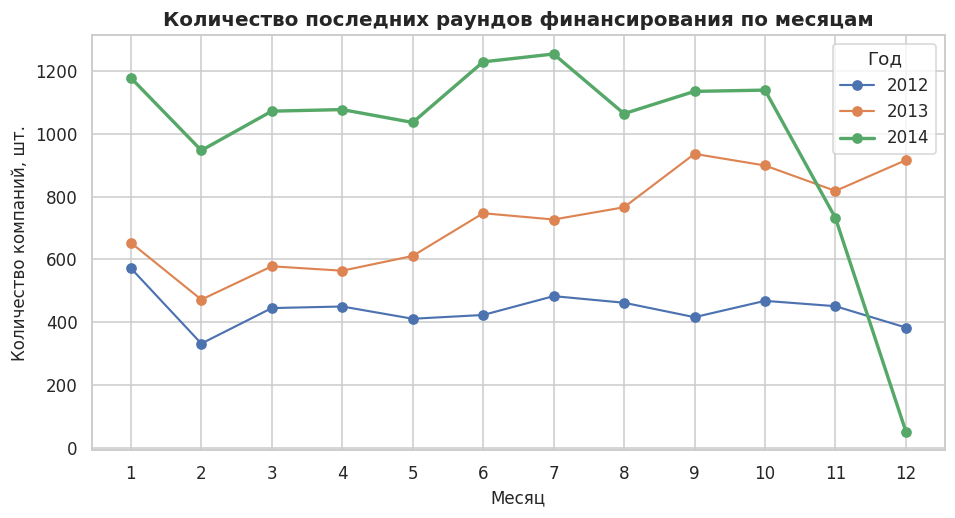

Январь-октябрь: в 2014 году в среднем 1113 записей в месяц против 695 в 2013, то есть на 60% больше
Ноябрь 2014: 732 записей против 818 в 2013 (89% от уровня прошлого года)
Декабрь 2014: 52 записей против 916 в 2013 (6% от уровня прошлого года)
Последняя дата финансирования в данных: 2014-12-31


In [27]:
# полные ли данные за 2014 год: смотрим, как раунды распределены по месяцам
by_month = (df[df['last_funding_at'].dt.year.isin([2012, 2013, 2014])]
            .groupby([df['last_funding_at'].dt.year.rename('год'),
                      df['last_funding_at'].dt.month.rename('месяц')])
            .size().unstack(0))
display(by_month)

fig, ax = plt.subplots(figsize=(10, 5))
for year in [2012, 2013, 2014]:
    ax.plot(by_month.index, by_month[year], marker='o',
            label=str(year), linewidth=2.2 if year == 2014 else 1.4)
ax.set_title('Количество последних раундов финансирования по месяцам')
ax.set_xlabel('Месяц')
ax.set_ylabel('Количество компаний, шт.')
ax.set_xticks(range(1, 13))
ax.legend(title='Год')
plt.show()

print('Январь-октябрь: в 2014 году в среднем %.0f записей в месяц против %.0f в 2013, то есть на %.0f%% больше' %
      (by_month.loc[1:10, 2014].mean(), by_month.loc[1:10, 2013].mean(),
       (by_month.loc[1:10, 2014].sum() / by_month.loc[1:10, 2013].sum() - 1) * 100))
print('Ноябрь 2014: %d записей против %d в 2013 (%.0f%% от уровня прошлого года)' %
      (by_month.loc[11, 2014], by_month.loc[11, 2013],
       by_month.loc[11, 2014] / by_month.loc[11, 2013] * 100))
print('Декабрь 2014: %d записей против %d в 2013 (%.0f%% от уровня прошлого года)' %
      (by_month.loc[12, 2014], by_month.loc[12, 2013],
       by_month.loc[12, 2014] / by_month.loc[12, 2013] * 100))
print('Последняя дата финансирования в данных:', df['last_funding_at'].max().date())

<div class="alert alert-success" id="review-F-057">
<b>Комментарий ревьюера:</b>☀️
Полнота 2014 года проверена по распределению внутри года

Полнота проверена так, как и надо: по помесячному распределению записей, а не по максимальной дате в столбце. График сразу показывает обрыв в конце года, и дальше на него можно опираться при сравнении 2014 года с 2013
</div>

In [28]:
# исключаем компании с аномальным объёмом финансирования
before = len(df)
data = df[~df['is_outlier']].copy()
print('Исключено аномальных компаний: %d (%.1f%%), осталось %d' %
      (before - len(data), (before - len(data)) / before * 100, len(data)))

Исключено аномальных компаний: 5244 (12.8%), осталось 35663


In [29]:
# сколько раундов финансирования приходится на каждый год
data['year'] = data['mid_funding_at'].dt.year
rounds_by_year = data.groupby('year')['funding_rounds'].sum()

active_years = rounds_by_year[rounds_by_year >= 50].index
print('Годы с 50 и более раундами финансирования: %d - %d (всего %d лет)' %
      (active_years.min(), active_years.max(), len(active_years)))
display(rounds_by_year[rounds_by_year.index >= 1995].to_frame('раундов'))

Годы с 50 и более раундами финансирования: 2000 - 2014 (всего 15 лет)


,раундов
year,
1995.00,9.00
1996.00,8.00
1997.00,5.00
1998.00,15.00
1999.00,43.00
2000.00,113.00
2001.00,66.00
2002.00,95.00
2003.00,124.00


In [30]:
# оставляем только компании, финансировавшиеся в годы с достаточной активностью рынка
before = len(data)
data = data[data['year'].isin(active_years)].copy()

data['year'] = data['year'].astype(int)   # после фильтрации пропусков в годе не осталось

print('Оставлено %d компаний из %d - отброшено %d (%.1f%%)' %
      (len(data), before, before - len(data), (before - len(data)) / before * 100))
print('Доля от данных после предобработки: %.1f%%' % (len(data) / len(df) * 100))
print('Период исследования: %d - %d годы' % (data['year'].min(), data['year'].max()))
print('Доля от исходных данных проекта: %.1f%%' % (len(data) / len(investments) * 100))
display(data[['name', 'market', 'funding_total_usd', 'funding_rounds', 'year']].head())

Оставлено 35589 компаний из 35663 - отброшено 74 (0.2%)
Доля от данных после предобработки: 87.0%
Период исследования: 2000 - 2014 годы
Доля от исходных данных проекта: 65.5%


,name,market,funding_total_usd,funding_rounds,year
1,University of New Brunswick,unknown,2000000.00,1.00,2014
2,DuPont,mid,9000000.00,1.00,2009
3,University of Michigan,Education,7700000.00,3.00,2013
4,Case Western Reserve University,Education,540000.00,1.00,2014
7,Duke University,Education,8700000.00,1.00,2014


<div class="alert alert-success" id="review-F-060">
<b>Комментарий ревьюера:</b>☀️
Порядок отсечения аномалий и отбора лет

Порядок шагов верный: сначала убраны аномалии, и только потом посчитаны раунды по годам и отобраны годы с полусотней раундов. При обратном порядке в выборку затесался бы лишний год на границе. Отбор идёт по `mid_funding_at` и сумме раундов, как просит задание, а потери на этом шаге посчитаны и названы
</div>

**Вывод по разделу 3.2.** Данные за 2014 год неполные, но выглядит это не так, как можно было бы ожидать. С января по октябрь 2014-й идёт заметно выше 2013-го: в среднем 1 113 записей в месяц против 695, то есть на 60 % больше. Ноябрь опускается до 89 % от прошлогоднего уровня, а декабрь обрывается совсем - 52 записи против 916, всего 6 %. На фоне растущего года такой провал выглядит ещё убедительнее: это не спад рынка, а граница выгрузки.

Последняя дата в данных - 31 декабря 2014 года, то есть отдельные записи доходят до конца года, но сам декабрь заполнен примерно на двадцатую часть от нормы. Поэтому годовые итоги 2014-го занижены, и сравнивать его с предыдущими годами по количеству сделок нельзя.

Аномальные компании убрали: 5 244 штуки, 12,8 %, осталось 35 663.

Порог в 50 раундов за год проходят 2000-2014 годы, все 15 лет, за которые есть данные о возвратах. Единичные раунды 1995-1999 годов отбросили, это 74 компании, 0,2 % выборки.

В итоге работаем с 35 589 компаниями. Это 87,0 % от очищенных данных и 65,5 % от исходной выгрузки. Объём достаточный: даже в самых маленьких массовых сегментах остаются сотни компаний.

<div class="alert alert-warning" id="review-F-061">
<b>Комментарий ревьюера:</b>⛅️
Сравнение месяцев 2014 и 2013 в выводе расходится с графиком

Сравнение месяцев в выводе не сходится с собственным графиком: с января по октябрь 2014 год идёт заметно выше 2013, местами почти вдвое, а не держится на его уровне. Для основной мысли это скорее плюс, обрыв в ноябре и декабре на таком фоне выглядит ещё резче, но формулировку стоит поправить. Заодно стоит перепроверить фразу про начало декабря: последняя дата в данных приходится на конец года
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Спасибо, формулировка была неточной. Добавил в код прямое сравнение месяцев и переписал вывод: с января по октябрь 2014-й идёт на 60 % выше 2013-го (в среднем 1 113 записей в месяц против 695), в ноябре опускается до 89 % от прошлогоднего уровня, а в декабре обрывается до 6 %. На фоне растущего года провал в декабре выглядит ещё убедительнее.

Фразу про начало декабря тоже поправил: последняя дата в данных действительно 31 декабря 2014 года, отдельные записи доходят до конца года, но сам декабрь заполнен примерно на двадцатую часть от нормы.

</div>

### 3.3. Анализ типов финансирования по объёму и популярности

Постройте график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируйтесь на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также постройте график, который покажет популярность разных типов финансирования - какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравните графики и выделите часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот - те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

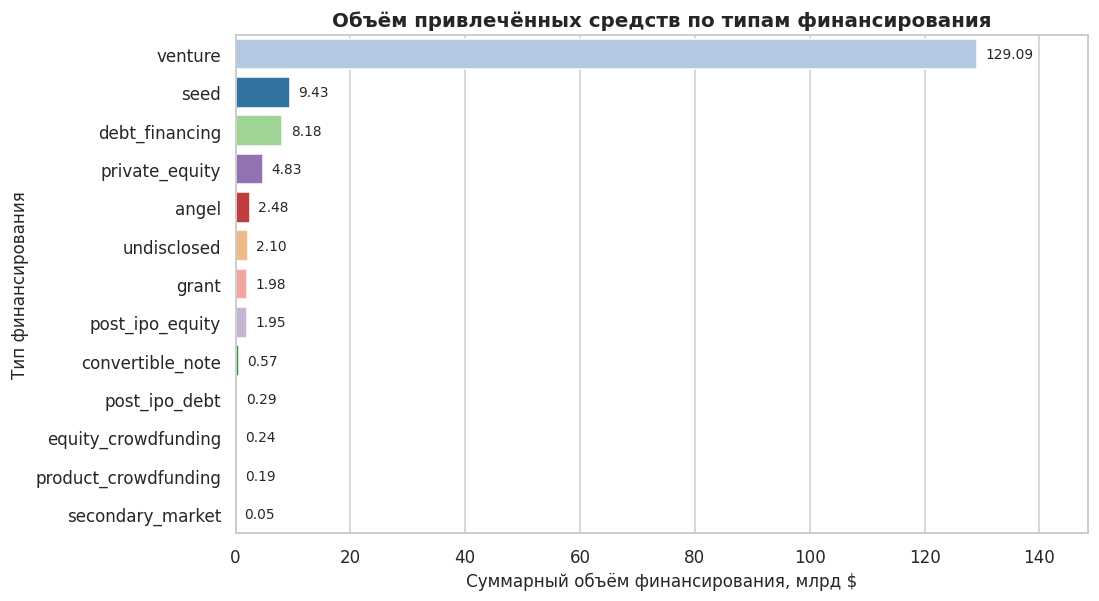

Всего привлечено: 161.4 млрд $
Из них венчур: 129.1 млрд $ (80.0%), все остальные типы вместе: 32.3 млрд $


In [31]:
# какие типы финансирования привлекли больше всего денег
volume = (data[FUNDING_TYPES].sum() / 1e9).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=volume.values, y=list(volume.index),
            palette=[TYPE_COLORS[t] for t in volume.index], ax=ax)
for i, v in enumerate(volume):
    ax.text(v + 1.5, i, '%.2f' % v, va='center', fontsize=9)
ax.set_title('Объём привлечённых средств по типам финансирования')
ax.set_xlabel('Суммарный объём финансирования, млрд $')
ax.set_ylabel('Тип финансирования')
ax.set_xlim(0, volume.max() * 1.15)
plt.show()

print('Всего привлечено: %.1f млрд $' % volume.sum())
print('Из них венчур: %.1f млрд $ (%.1f%%), все остальные типы вместе: %.1f млрд $' %
      (volume.iloc[0], volume.iloc[0] / volume.sum() * 100, volume.sum() - volume.iloc[0]))

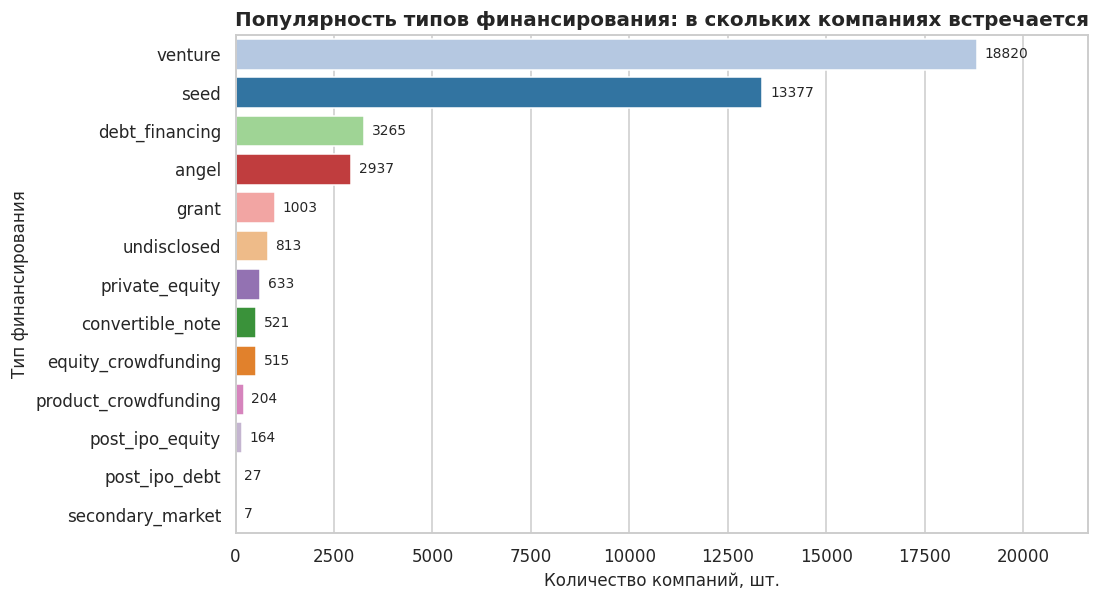

,"объём, млрд $",компаний,"средний объём на компанию, млн $"
post_ipo_equity,1.95,164,11.87
post_ipo_debt,0.29,27,10.62
private_equity,4.83,633,7.62
venture,129.09,18820,6.86
secondary_market,0.05,7,6.47
undisclosed,2.10,813,2.58
debt_financing,8.18,3265,2.50
grant,1.98,1003,1.97
convertible_note,0.57,521,1.09
product_crowdfunding,0.19,204,0.91


In [32]:
# насколько популярны разные типы финансирования и каков средний чек
popularity = (data[FUNDING_TYPES] > 0).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=popularity.values, y=list(popularity.index),
            palette=[TYPE_COLORS[t] for t in popularity.index], ax=ax)
for i, v in enumerate(popularity):
    ax.text(v + 200, i, '%d' % v, va='center', fontsize=9)
ax.set_title('Популярность типов финансирования: в скольких компаниях встречается')
ax.set_xlabel('Количество компаний, шт.')
ax.set_ylabel('Тип финансирования')
ax.set_xlim(0, popularity.max() * 1.15)
plt.show()

# сопоставляем объём и популярность: где много денег на одну компанию, а где - мало
compare = pd.DataFrame({'объём, млрд $': volume.round(2),
                        'компаний': popularity})
compare['средний объём на компанию, млн $'] = (data[FUNDING_TYPES].sum() / popularity / 1e6).round(2)
display(compare.sort_values('средний объём на компанию, млн $', ascending=False))

<div class="alert alert-warning" id="review-F-064">
<b>Комментарий ревьюера:</b>⛅️
Палитра и порядок мешают сравнить два графика между собой

Два графика, которые задание просит сравнить между собой, раскрашены разными палитрами, и цвет в каждом привязан к месту в рейтинге, а не к типу финансирования. Из-за этого `venture` меняет цвет от графика к графику, а глазу при сопоставлении не за что зацепиться. В разделе про группы по срокам это сделано ровно так, как нужно: единый словарь цветов держит категорию одинаковой на обеих панелях, и тот же приём просится сюда
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Сделал так же, как в разделе про группы: добавил словарь `TYPE_COLORS`, где цвет закреплён за типом финансирования, и оба графика теперь берут цвета из него. Venture окрашен одинаково и на графике объёмов, и на графике популярности, так что глазу есть за что зацепиться при сравнении.

</div>

Постройте график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

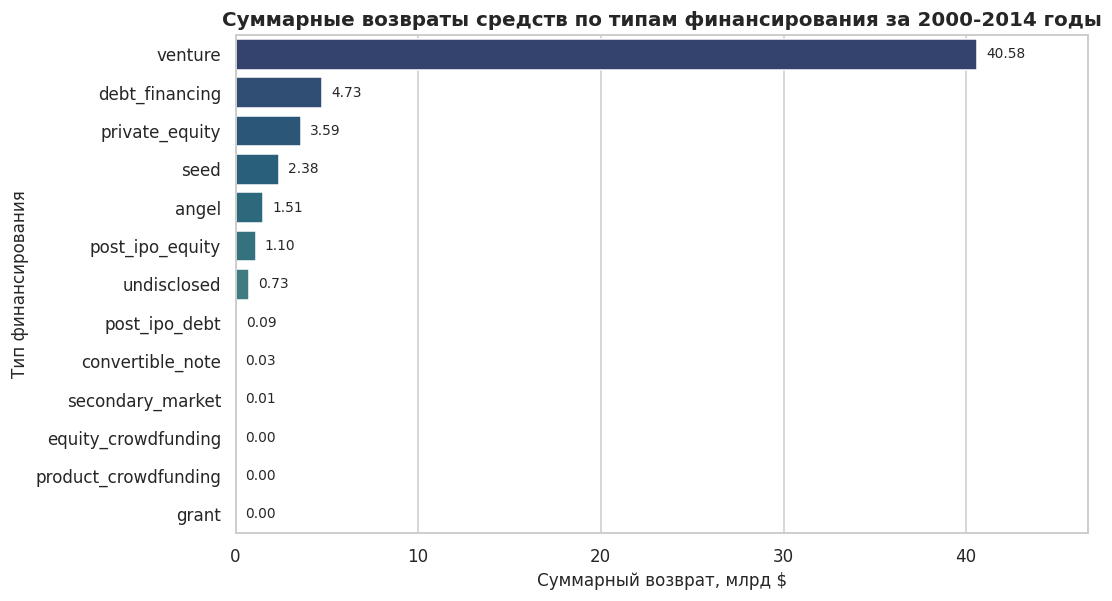

Доля венчура в общем объёме возвратов: 74.1%


In [33]:
# суммарные возвраты по типам финансирования за весь период
returns_total = returns.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=(returns_total / 1000).values, y=list(returns_total.index), palette='crest_r', ax=ax)
for i, v in enumerate(returns_total / 1000):
    ax.text(v + 0.5, i, '%.2f' % v, va='center', fontsize=9)
ax.set_title('Суммарные возвраты средств по типам финансирования за 2000-2014 годы')
ax.set_xlabel('Суммарный возврат, млрд $')
ax.set_ylabel('Тип финансирования')
ax.set_xlim(0, (returns_total / 1000).max() * 1.15)
plt.show()

print('Доля венчура в общем объёме возвратов: %.1f%%' % (returns_total.iloc[0] / returns_total.sum() * 100))

In [34]:
# сопоставляем возвраты с вложениями: сколько вернулось на каждый вложенный доллар
compare_ret = pd.DataFrame({
    'вложено, млрд $': (data[FUNDING_TYPES].sum() / 1e9).round(2),
    'возвращено, млрд $': (returns.sum()[FUNDING_TYPES] / 1000).round(2)
})
compare_ret['возврат на доллар'] = (compare_ret['возвращено, млрд $'] /
                                    compare_ret['вложено, млрд $']).round(2)
display(compare_ret.sort_values('возврат на доллар', ascending=False))

print('Важно: возвраты в cb_returns относятся ко всему рынку, а вложения посчитаны')
print('по отфильтрованной выборке, поэтому отношение стоит читать как относительный ориентир,')
print('а не как точную доходность.')

,"вложено, млрд $","возвращено, млрд $",возврат на доллар
private_equity,4.83,3.59,0.74
angel,2.48,1.51,0.61
debt_financing,8.18,4.73,0.58
post_ipo_equity,1.95,1.10,0.56
undisclosed,2.10,0.73,0.35
venture,129.09,40.58,0.31
post_ipo_debt,0.29,0.09,0.31
seed,9.43,2.38,0.25
secondary_market,0.05,0.01,0.20
convertible_note,0.57,0.03,0.05


Важно: возвраты в cb_returns относятся ко всему рынку, а вложения посчитаны
по отфильтрованной выборке, поэтому отношение стоит читать как относительный ориентир,
а не как точную доходность.


<div class="alert alert-success" id="review-F-067">
<b>Комментарий ревьюера:</b>☀️
Единицы возвратов и вложений сведены корректно

Единицы сведены как надо: возвраты переведены из миллионов в миллиарды и сопоставляются с вложениями в тех же миллиардах. Важно и то, что рядом сказано, почему это отношение нельзя читать как доходность: возвраты собраны по всему рынку, а вложения посчитаны по отфильтрованной выборке
</div>

**Вывод по разделу 3.3.** Из 161,4 млрд долл., которые привлекли компании выборки, на венчур приходится 129,1 млрд, то есть 80,0 %. Все остальные двенадцать типов вместе дают 32,3 млрд: посевные инвестиции 9,4 млрд, долговое финансирование 8,2 млрд, private equity 4,8 млрд, ангельские инвестиции 2,5 млрд.

По популярности порядок похожий: венчур встречается у 18 820 компаний, посевные инвестиции у 13 377, долговое финансирование у 3 265, ангельские у 2 937. Остальные инструменты набирают единицы и десятки компаний.

Цвет на обоих графиках закреплён за типом финансирования, так что их можно сравнивать напрямую. И тогда видно две группы-исключения:

- Часто, но по мелочи. Посевные инвестиции идут вторыми по популярности, но дают всего 0,71 млн долл. на компанию. У ангельских 0,84 млн, у долевого краудфандинга 0,46 млн. Это инструменты ранней стадии: сделок много, чеки маленькие.
- Редко, но помногу. Финансирование после IPO встречается всего у 164 компаний, зато по 11,9 млн долл. на каждую. Долговое финансирование после IPO - 27 компаний по 10,6 млн, private equity - 633 компании по 7,6 млн. Это уже про зрелые компании.

Возвраты повторяют структуру вложений. За 2000-2014 годы больше всего вернул венчур: 40,6 млрд долл., или 74,1 % всех возвратов. Дальше идут долговое финансирование (4,7 млрд), private equity (3,6 млрд), посевные (2,4 млрд) и ангельские инвестиции (1,5 млрд). По грантам возвратов нет вообще, что логично, ведь грант не возвращают.

Если поделить возвраты на вложения, лучший результат у private equity (0,74) и ангельских инвестиций (0,61), а у венчура 0,31. Читать это как доходность нельзя: возвраты в `cb_returns` относятся ко всему рынку, вложения посчитаны по отфильтрованной выборке, да и деньги возвращаются с задержкой в несколько лет. Сравнивать типы корректнее по динамике, этим займёмся в разделе 4.3.

<div class="alert alert-success" id="review-F-068">
<b>Комментарий ревьюера:</b>☀️
Контрастные пары типов финансирования названы верно

Контрастные пары названы именно те, о которых спрашивает задание: частые и мелкие посевные с ангельскими против редких и крупных инструментов зрелой стадии. Числа сверены с таблицами и сходятся, а нулевые возвраты по грантам объяснены предметной особенностью, а не списаны на ошибку данных
</div>

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитайте для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы постройте графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

Когда будете строить графики в этом задании и следующих, используйте данные только по тем компаниям, которые остались в датасете после предыдущих фильтраций.

На основе полученных данных ответьте на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

In [35]:
# средний объём одного раунда финансирования для каждой компании
data['avg_round'] = data['funding_total_usd'] / data['funding_rounds']

display(data[['name', 'funding_total_usd', 'funding_rounds', 'avg_round', 'year']].head())
print('Медианный размер одного раунда по всей выборке: %s $' % money(data['avg_round'].median()))

,name,funding_total_usd,funding_rounds,avg_round,year
1,University of New Brunswick,2000000.00,1.00,2000000.00,2014
2,DuPont,9000000.00,1.00,9000000.00,2009
3,University of Michigan,7700000.00,3.00,2566666.67,2013
4,Case Western Reserve University,540000.00,1.00,540000.00,2014
7,Duke University,8700000.00,1.00,8700000.00,2014


Медианный размер одного раунда по всей выборке: 1M $


<div class="alert alert-success" id="review-p2-01">
<b>Комментарий ревьюера:</b>☀️
Размер одного раунда посчитан по компаниям, типичное значение взято медианой

Размер одного раунда посчитан именно так, как нужно для вопроса заказчика: общий объём делится на число раундов внутри каждой компании, а не по агрегатам года. Типичное значение при этом взято медианой, и при таком длинном правом хвосте это правильный выбор: пара крупных сделок не вытягивает всю картину вверх
</div>

In [36]:
# динамика по годам: типичный размер раунда и активность рынка
dynamics = data.groupby('year').agg(
    медиана_раунда=('avg_round', 'median'),
    средний_раунд=('avg_round', 'mean'),
    раундов=('funding_rounds', 'sum'),
    компаний=('name', 'size'))
display(dynamics.round(0))

,медиана_раунда,средний_раунд,раундов,компаний
year,,,,
2000,2250000.00,4492723.00,113.00,65
2001,1570886.00,3366817.00,66.00,37
2002,2833333.00,4054599.00,95.00,47
2003,1475000.00,3326901.00,124.00,62
2004,3000000.00,4712111.00,179.00,94
2005,4500000.00,5808706.00,946.00,696
2006,3900000.00,5355825.00,1841.00,1161
2007,2883333.00,4679497.00,2826.00,1591
2008,2174244.00,4331301.00,3644.00,1974


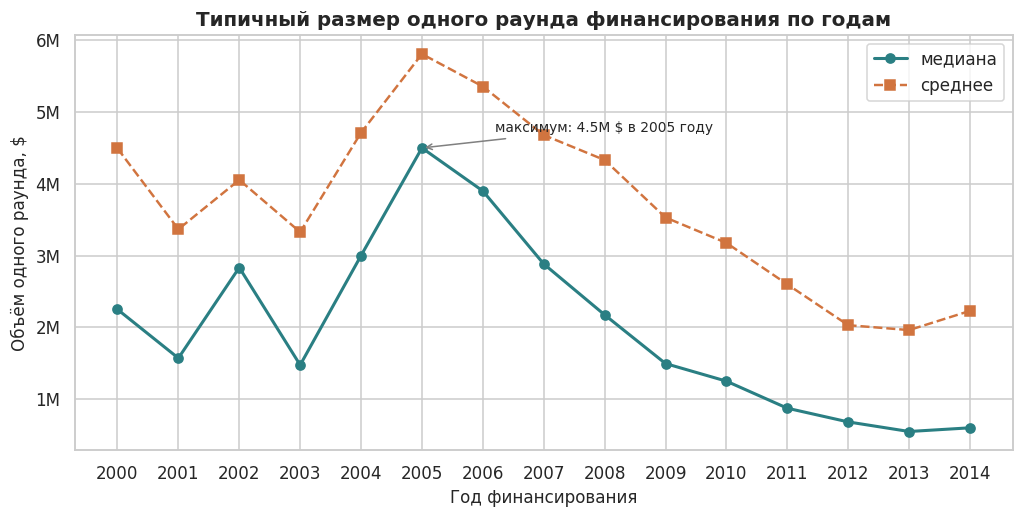

In [37]:
# динамика типичного размера одного раунда
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(dynamics.index, dynamics['медиана_раунда'], marker='o', color='#2a7f83',
        linewidth=2, label='медиана')
ax.plot(dynamics.index, dynamics['средний_раунд'], marker='s', color='#d1743f',
        linewidth=1.6, linestyle='--', label='среднее')

best_year = dynamics['медиана_раунда'].idxmax()
ax.annotate('максимум: %s $ в %d году' % (money(dynamics['медиана_раунда'].max()), best_year),
            xy=(best_year, dynamics['медиана_раунда'].max()),
            xytext=(best_year + 1.2, dynamics['медиана_раунда'].max() * 1.05),
            arrowprops={'arrowstyle': '->', 'color': 'grey'}, fontsize=9)

ax.set_title('Типичный размер одного раунда финансирования по годам')
ax.set_xlabel('Год финансирования')
ax.set_ylabel('Объём одного раунда, $')
ax.yaxis.set_major_formatter(MONEY_FMT)
ax.set_xticks(dynamics.index)
ax.legend()
plt.show()

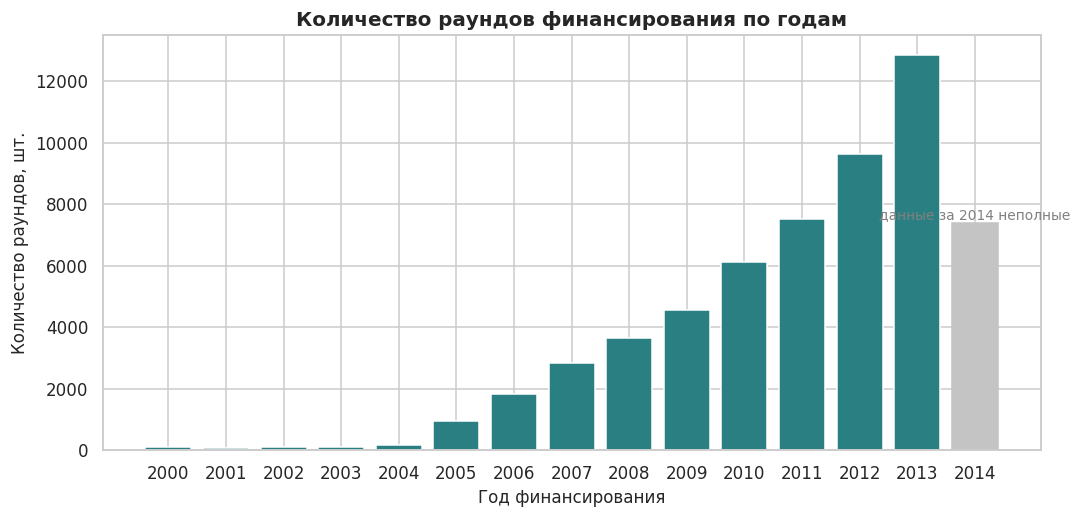

In [38]:
# динамика активности рынка - общее количество раундов за год
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(dynamics.index, dynamics['раундов'], color='#2a7f83')
bars[-1].set_color('#c4c4c4')

ax.set_title('Количество раундов финансирования по годам')
ax.set_xlabel('Год финансирования')
ax.set_ylabel('Количество раундов, шт.')
ax.set_xticks(dynamics.index)
ax.text(dynamics.index[-1], dynamics['раундов'].iloc[-1] * 1.02,
        'данные за 2014 неполные', ha='center', fontsize=9, color='grey')
plt.show()

<div class="alert alert-success" id="review-p2-02">
<b>Комментарий ревьюера:</b>☀️
Неполнота 2014 года отмечена прямо на графике активности

График числа раундов сделан аккуратно: у 2014 года отдельный цвет и подпись о неполных данных прямо в поле графика. Читатель не примет усечённую выгрузку за реальный обвал рынка, и для отчёта заказчику это ровно та деталь, которая экономит спор на встрече
</div>

In [39]:
# ответы на вопросы задания
best_year = int(dynamics['медиана_раунда'].idxmax())
print('1. Максимальный типичный размер раунда - в %d году: %s $ (среднее: %s $)' %
      (best_year, money(dynamics.loc[best_year, 'медиана_раунда']),
       money(dynamics.loc[best_year, 'средний_раунд'])))
print()
print('2. Динамика 2014 года по сравнению с 2013:')
print('   раундов: %d против %d (%.1f%%)' %
      (dynamics.loc[2014, 'раундов'], dynamics.loc[2013, 'раундов'],
       (dynamics.loc[2014, 'раундов'] / dynamics.loc[2013, 'раундов'] - 1) * 100))
print('   медиана раунда: %s $ против %s $ (%+.1f%%)' %
      (money(dynamics.loc[2014, 'медиана_раунда']), money(dynamics.loc[2013, 'медиана_раунда']),
       (dynamics.loc[2014, 'медиана_раунда'] / dynamics.loc[2013, 'медиана_раунда'] - 1) * 100))
print('   средний раунд: %s $ против %s $ (%+.1f%%)' %
      (money(dynamics.loc[2014, 'средний_раунд']), money(dynamics.loc[2013, 'средний_раунд']),
       (dynamics.loc[2014, 'средний_раунд'] / dynamics.loc[2013, 'средний_раунд'] - 1) * 100))
print()
print('3. Масштаб изменений за период:')
print('   медиана раунда снизилась с %d по 2013 год в %.1f раза' %
      (best_year, dynamics.loc[best_year, 'медиана_раунда'] / dynamics.loc[2013, 'медиана_раунда']))
print('   количество раундов выросло с 2000 по 2013 год в %.0f раз' %
      (dynamics.loc[2013, 'раундов'] / dynamics.loc[2000, 'раундов']))

1. Максимальный типичный размер раунда - в 2005 году: 4.5M $ (среднее: 5.809M $)

2. Динамика 2014 года по сравнению с 2013:
   раундов: 7380 против 12861 (-42.6%)
   медиана раунда: 600K $ против 548.7K $ (+9.4%)
   средний раунд: 2.229M $ против 1.962M $ (+13.6%)

3. Масштаб изменений за период:
   медиана раунда снизилась с 2005 по 2013 год в 8.2 раза
   количество раундов выросло с 2000 по 2013 год в 114 раз


**Вывод по разделу 4.1.** Максимальный типичный размер раунда пришёлся на 2005 год - 4,5 млн долл. при среднем 5,8 млн. Дальше медиана снижалась восемь лет подряд и к 2013 году упала в 8,2 раза, до 549 тыс. долл.

Само по себе это не кризис. Венчур стал массовым: появились посевные фонды и акселераторы, порог входа снизился, сделок стало кратно больше, но каждая мельче. Число раундов выросло со 113 в 2000 году до 12 861 в 2013-м, в 114 раз.

В 2014 году многолетнее снижение прекратилось: медиана выросла на 9,4 % (с 549 до 600 тыс. долл.), средний размер раунда прибавил 13,6 % (с 1,96 до 2,23 млн). Это первый разворот с 2005 года, и он посчитан по компаниям, а не по объёму выгрузки, так что неполнота года на него почти не влияет.

А вот про количество сделок в 2014 году судить рано. Формально раундов 7 380 против 12 861, то есть на 42,6 % меньше, но год в данных не закрыт: декабрь заполнен на 6 % от нормы, а до ноября 2014-й шёл заметно выше 2013-го. Пока год не закрыт, из этой цифры не выводится ни спад рынка, ни ослабление конкуренции за проекты. Надёжный вывод здесь один: типичный чек перестал падать и начал расти.

<div class="alert alert-warning" id="review-p2-03">
<b>Комментарий ревьюера:</b>⛅️
Вывод о сдвиге рынка опирается на число сделок неполного года

Вывод о сдвиге рынка к меньшему числу крупных сделок держится на падении числа раундов, которое здесь же названо следствием неполного года. Из усечённой выгрузки не выводится ни сам сдвиг, ни меньшая конкуренция за проект в 2015 году: про число сделок 2014 года пока просто нечего сказать. Аккуратнее прозвучит более узкая формулировка: снижение медианы прекратилось, а судить о количестве сделок рано, пока год не закрыт
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Согласен, вывод был шире данных. Переписал: теперь про количество сделок в 2014 году сказано прямо, что судить рано - год в данных не закрыт, а до ноября он шёл выше 2013-го. Утверждение про сдвиг рынка и меньшую конкуренцию убрал.

Осталось то, что действительно следует из расчёта: многолетнее снижение типичного размера раунда прекратилось. После пересчёта дат среднего раунда медиана 2014 года даже выросла на 9,4 % (с 549 до 600 тыс. долл.), средний чек - на 13,6 %. Этот показатель считается по компаниям, а не по объёму выгрузки, поэтому неполнота года на него почти не влияет.

</div>

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составьте сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберите из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразите, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматривайте только массовые сегменты, а средние и нишевые исключите.

На основе графика сделайте вывод о том, какие сегменты показывают наиболее быстрый и уверенный рост.

Массовых сегментов: 48, из них выросли в 2014 году: 13


,"2013, млн $","2014, млн $","рост, %"
market,,,
Medical,63.00,176.00,178.40
Apps,28.00,69.00,144.60
Startups,18.00,42.00,129.50
Technology,123.00,226.00,83.90
Internet,70.00,118.00,69.00
SaaS,75.00,98.00,29.20
Manufacturing,360.00,454.00,26.00
Real Estate,97.00,116.00,19.60
Design,61.00,69.00,13.00


Насколько ровной была траектория отобранных сегментов:


,"рост 2014 к 2013, %",лет со снижением с 2009
market,,
Medical,178.40,1
Big Data,4.10,1
Photography,2.80,1
Apps,144.60,2
Startups,129.50,2
Internet,69.00,2
SaaS,29.20,2
Design,13.00,2
Social Network Media,8.80,2


Суммарное финансирование по годам, млн $:


market,Medical,Apps,Startups,Technology,Internet,SaaS,Manufacturing,Real Estate,Design,Social Network Media,Big Data,Photography,News
year,,,,,,,,,,,,,
2008,29.00,3.00,5.00,288.00,23.00,27.00,173.00,47.00,6.00,11.00,1.00,21.00,87.00
2009,12.00,7.00,0.00,36.00,38.00,14.00,426.00,39.00,2.00,9.00,2.00,30.00,41.00
2010,26.00,6.00,2.00,296.00,37.00,33.00,244.00,37.00,17.00,24.00,39.00,17.00,107.00
2011,29.00,18.00,20.00,126.00,37.00,32.00,558.00,20.00,9.00,15.00,53.00,39.00,48.00
2012,44.00,32.00,12.00,191.00,28.00,50.00,520.00,73.00,39.00,22.00,96.00,44.00,98.00
2013,63.00,28.00,18.00,123.00,70.00,75.00,360.00,97.00,61.00,24.00,76.00,48.00,62.00
2014,176.00,69.00,42.00,226.00,118.00,98.00,454.00,116.00,69.00,27.00,79.00,50.00,62.00


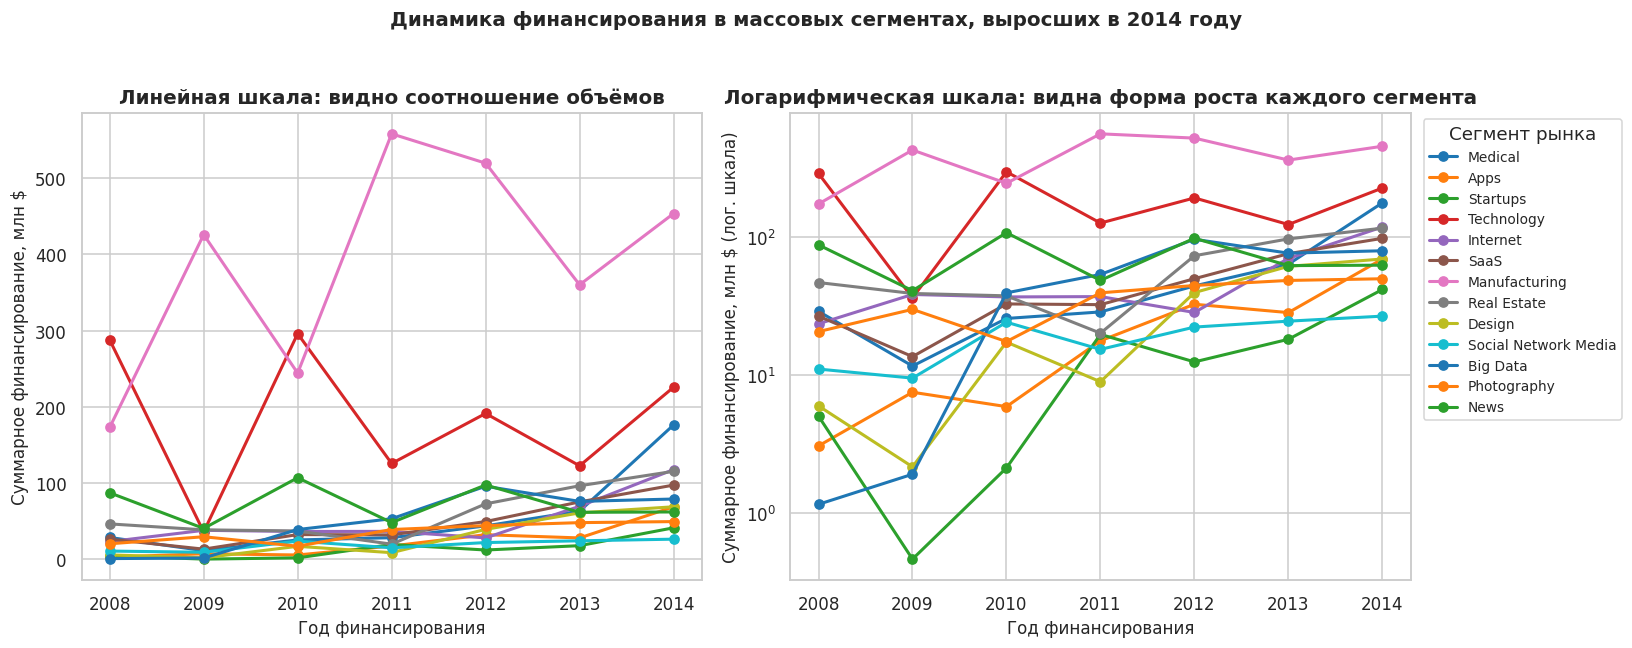

In [40]:
# сводная таблица: суммарное финансирование по годам и сегментам рынка
pivot = data.pivot_table(index='year', columns='market', values='funding_total_usd', aggfunc='sum').fillna(0)

# рассматриваем только массовые сегменты: заглушки mid, niche и unknown исключаем
mass_cols = [c for c in pivot.columns if c not in ('mid', 'niche', 'unknown')]
pivot_mass = pivot[mass_cols]

# отбираем сегменты, выросшие в 2014 году по сравнению с 2013
growing = [c for c in pivot_mass.columns if pivot_mass.loc[2014, c] > pivot_mass.loc[2013, c]]
growth = ((pivot_mass.loc[2014, growing] / pivot_mass.loc[2013, growing] - 1) * 100).sort_values(ascending=False)

print('Массовых сегментов: %d, из них выросли в 2014 году: %d' % (len(mass_cols), len(growing)))
display(pd.DataFrame({'2013, млн $': (pivot_mass.loc[2013, growth.index] / 1e6).round(0),
                      '2014, млн $': (pivot_mass.loc[2014, growth.index] / 1e6).round(0),
                      'рост, %': growth.round(1)}))

# график строим с 2008 года - раньше данных по этим сегментам почти нет
plot_years = pivot_mass.loc[2008:2014, growth.index] / 1e6

# рост в последнем году - это ещё не устойчивость, поэтому считаем и число лет со снижением
declines = (plot_years.diff().iloc[1:] < 0).sum()
profile = pd.DataFrame({'рост 2014 к 2013, %': growth.round(1),
                        'лет со снижением с 2009': declines[growth.index]})
print('Насколько ровной была траектория отобранных сегментов:')
display(profile.sort_values(['лет со снижением с 2009', 'рост 2014 к 2013, %'], ascending=[True, False]))

print('Суммарное финансирование по годам, млн $:')
display(plot_years.round(0))

# на линейной шкале Manufacturing и Technology прижимают остальные линии к нулю,
# поэтому рядом строим ту же динамику в логарифмическом масштабе
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True)
palette = sns.color_palette('tab10', len(growth.index))

for color, segment in zip(palette, growth.index):
    axes[0].plot(plot_years.index, plot_years[segment], marker='o', linewidth=2,
                 color=color, label=segment)
    axes[1].plot(plot_years.index, plot_years[segment], marker='o', linewidth=2,
                 color=color, label=segment)

axes[0].set_title('Линейная шкала: видно соотношение объёмов')
axes[0].set_xlabel('Год финансирования')
axes[0].set_ylabel('Суммарное финансирование, млн $')
axes[0].set_xticks(plot_years.index)

axes[1].set_yscale('log')
axes[1].set_title('Логарифмическая шкала: видна форма роста каждого сегмента')
axes[1].set_xlabel('Год финансирования')
axes[1].set_ylabel('Суммарное финансирование, млн $ (лог. шкала)')
axes[1].legend(title='Сегмент рынка', fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1))

fig.suptitle('Динамика финансирования в массовых сегментах, выросших в 2014 году',
             fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

<div class="alert alert-success" id="review-p2-04">
<b>Комментарий ревьюера:</b>☀️
Отбор растущих массовых сегментов собран корректно

Сводная таблица и отбор растущих сегментов собраны по правилам задания: расчёт идёт по отфильтрованному набору, укрупнённые mid и niche исключены вместе с заглушкой unknown, за которой реальной отрасли нет. Рядом с графиком выведены и проценты роста, и сами суммы по годам, так что вывод можно проверить по числам, а не только по линиям
</div>

**Вывод по разделу 4.2.** Из 48 массовых сегментов финансирование в 2014 году выросло у тринадцати. Рынок в целом сжимался, так что рост был скорее исключением.

Смотреть только на прирост последнего года мало: он ничего не говорит о том, как сегмент шёл до этого. Поэтому рядом посчитано, сколько лет с 2009-го объём в сегменте снижался.

| Сегмент | Рост 2014 к 2013 | Объём 2014, млн долл. | Лет со снижением с 2009 |
|---|---|---|---|
| Medical | +178 % | 176 | 1 |
| Apps | +145 % | 69 | 2 |
| Startups | +130 % | 42 | 2 |
| Technology | +84 % | 226 | 3 |
| Internet | +69 % | 118 | 2 |
| SaaS | +29 % | 98 | 2 |
| Manufacturing | +26 % | 454 | 3 |
| Real Estate | +20 % | 116 | 3 |
| Design | +13 % | 69 | 2 |
| Social Network Media | +9 % | 27 | 2 |
| Big Data | +4 % | 79 | 1 |
| Photography | +3 % | 50 | 1 |
| News | +1 % | 62 | 3 |

Medical выигрывает по обоим критериям сразу: самый быстрый рост в 2014 году и всего одна просадка за шесть лет - в кризисном 2009-м. С 2010 года сегмент растёт непрерывно: 26, 29, 44, 63 и 176 млн долл., причём в последний год почти втрое.

Big Data и Photography тоже просели всего однажды, но прибавили копейки (+4 % и +3 %), то есть они скорее стабильны, чем растут.

SaaS и Design ровными назвать нельзя, хотя на графике это почти не видно: у обоих по два года со снижением - 2009-й и 2011-й, причём Design в 2011 году потерял почти половину объёма (17 → 9 млн долл.), а SaaS просел символически (33 → 32 млн). Зато с 2012 года оба растут без остановок: SaaS 50, 75, 98 млн, Design 39, 61, 69 млн. Ставить на них можно, но именно как на растущие последние три года, а не как на образец непрерывного роста.

Technology и Manufacturing крупнее всех по объёму, но у обоих по три года со снижением, и рост 2014 года укладывается в их обычные колебания.

График сделан в двух шкалах: на линейной видно соотношение объёмов (Manufacturing и Technology прижимают остальных к нулю), на логарифмической - форма роста каждого сегмента, включая просадки маленьких.

И ещё раз про 2014 год: данные неполные, поэтому реальные темпы роста у всех этих сегментов выше приведённых.

<div class="alert alert-warning" id="review-p2-05">
<b>Комментарий ревьюера:</b>⛅️
Оценка роста SaaS и Design расходится с таблицей

SaaS и Design названы ростом без единого спада, хотя в таблице рядом у SaaS 2011 год ниже 2010-го, а у Design почти вдвое меньше. На графике просадку почти не видно: Manufacturing и Technology растягивают ось и прижимают остальные линии к нулю, поэтому сверяться здесь надёжнее с таблицей. Формулировку про устойчивость этих двух сегментов стоит поправить, а сами сегменты удобно ранжировать по числу лет со снижением
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Спасибо, поймал. Сверился с таблицей: у SaaS 2011 год ниже 2010-го (33 - 32 млн долл.), у Design просадка вдвое (17 - 9 млн). Формулировку про рост без спада убрал.

В код добавил подсчёт числа лет со снижением с 2009 года, и теперь сегменты ранжируются не только по приросту последнего года, но и по ровности траектории. Заодно сделал график в двух шкалах: на линейной видно соотношение объёмов, на логарифмической - форма роста каждого сегмента, включая просадки маленьких, которые раньше прижимались к нулю.

Итог получился даже нагляднее: у Medical всего одна просадка за шесть лет и максимальный прирост, так что основная ставка подтвердилась.

</div>

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Ваша цель - для каждого года и каждого вида финансирования рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

Совет: когда будете делить сумму возвращённых средств на суммарный объём привлечённого финансирования по конкретному году, добавьте к знаменателю небольшое число, например `1e-60`. Это поможет избежать деления на ноль.

In [41]:
# доля возврата: сколько вернулось на каждый вложенный доллар в этом году и этом типе
funding_by_year = data.groupby('year')[FUNDING_TYPES].sum()
returns_usd = returns[FUNDING_TYPES] * 1e6          # в cb_returns суммы указаны в миллионах

# 1e-60 в знаменателе страхует от деления на ноль в годах, где такого финансирования не было
norm_returns = returns_usd / (funding_by_year + 1e-60)

# из-за нулевых знаменателей появляются заведомо нереальные значения - заменяем их пропусками
LIMIT = 3
outliers_count = (norm_returns > LIMIT).sum().sum()
norm_returns = norm_returns.mask(norm_returns > LIMIT)

print('Заменено на пропуски аномальных значений: %d из %d' % (outliers_count, norm_returns.size))
display(norm_returns.round(2))

Заменено на пропуски аномальных значений: 22 из 195


,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,1.00,0.17,0.00,0.70,0.00,0.62,0.27,0.00,0.00,0.27,0.00,0.03,0.00
2001,1.08,0.11,0.00,0.59,0.01,0.77,1.18,0.00,0.00,NaN,0.00,NaN,0.00
2002,0.63,0.70,0.00,0.61,NaN,0.27,1.14,0.00,0.20,1.13,0.00,NaN,0.00
2003,0.51,0.61,0.00,0.91,NaN,1.04,0.61,0.00,NaN,NaN,0.00,NaN,0.00
2004,0.55,0.84,0.00,0.53,NaN,0.44,0.83,0.00,NaN,NaN,0.00,NaN,0.00
2005,0.67,0.55,0.00,1.07,NaN,0.34,0.51,0.00,0.48,0.73,0.00,NaN,0.00
2006,0.95,0.34,0.20,0.76,0.17,0.81,0.67,0.00,0.94,NaN,0.00,NaN,0.00
2007,0.38,0.30,NaN,0.51,0.23,0.60,0.82,0.00,0.58,2.03,0.00,NaN,0.00
2008,0.31,0.19,NaN,0.34,0.06,0.95,0.41,0.00,0.68,2.34,0.00,NaN,0.00


<div class="alert alert-success" id="review-p2-06">
<b>Комментарий ревьюера:</b>☀️
Единицы возвратов и вложений сведены, правило отсечения аномалий названо

Единицы сведены до деления: возвраты переведены из миллионов в доллары, поэтому доля возврата получается в сопоставимом масштабе, а не занижена в миллион раз. Правило отсечения аномальных отношений названо прямо, и рядом видно, скольких значений оно коснулось
</div>

Постройте график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

Сделайте вывод о том, в каких типах финансирования наблюдается наиболее устойчивый рост показателя.

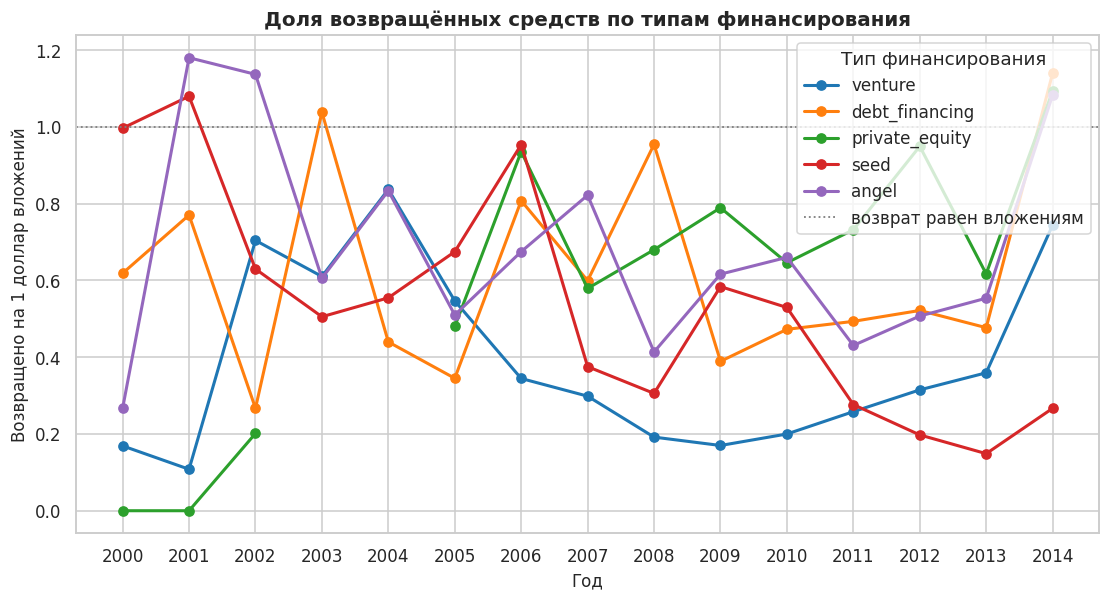

Тренд доли возврата за 2009-2014 годы:
venture          +0.097 в год, R2 = 0.75, 0.17 (2009) -> 0.74 (2014), изменение в 4.4 раза
debt_financing   +0.108 в год, R2 = 0.54, 0.39 (2009) -> 1.14 (2014), изменение в 2.9 раза
private_equity   +0.047 в год, R2 = 0.23, 0.79 (2009) -> 1.09 (2014), изменение в 1.4 раза
seed             -0.080 в год, R2 = 0.70, 0.58 (2009) -> 0.27 (2014), изменение в 0.5 раза
angel            +0.060 в год, R2 = 0.23, 0.62 (2009) -> 1.08 (2014), изменение в 1.8 раза


In [42]:
# динамика доли возврата по ключевым типам финансирования
key_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
key_colors = dict(zip(key_types, sns.color_palette('tab10', len(key_types))))

fig, ax = plt.subplots(figsize=(12, 6))
for t in key_types:
    ax.plot(norm_returns.index, norm_returns[t], marker='o', linewidth=2,
            color=key_colors[t], label=t)

ax.axhline(1, color='grey', linestyle=':', linewidth=1.2, label='возврат равен вложениям')
ax.set_title('Доля возвращённых средств по типам финансирования')
ax.set_xlabel('Год')
ax.set_ylabel('Возвращено на 1 доллар вложений')
ax.set_xticks(norm_returns.index)
ax.legend(title='Тип финансирования')
plt.show()

# оцениваем устойчивость роста линейным трендом за последние 6 лет
print('Тренд доли возврата за 2009-2014 годы:')
for t in key_types:
    s = norm_returns.loc[2009:2014, t].dropna()
    slope, intercept, rvalue, pvalue, stderr = stats.linregress(s.index, s.values)
    print('%-16s %+.3f в год, R2 = %.2f, %.2f (2009) -> %.2f (2014), изменение в %.1f раза' %
          (t, slope, rvalue ** 2, s.iloc[0], s.iloc[-1], s.iloc[-1] / s.iloc[0]))

**Вывод по разделу 4.3.** Долю возврата считали как отношение возвращённых денег к привлечённым в том же году и по тому же типу финансирования. 22 значения из 195 оказались нереальными, с возвратом больше вложений втрое и выше. Все они пришлись на годы, когда финансирования такого типа почти не было, поэтому мы заменили их пропусками.

| Тип финансирования | 2009 | 2014 | Тренд | Устойчивость (R²) |
|---|---|---|---|---|
| venture | 0,17 | 0,74 | +0,10 в год | 0,75 |
| debt_financing | 0,39 | 1,14 | +0,11 в год | 0,54 |
| private_equity | 0,79 | 1,09 | +0,05 в год | 0,23 |
| angel | 0,62 | 1,08 | +0,06 в год | 0,23 |
| seed | 0,58 | 0,27 | -0,08 в год | 0,70 |

Самый ровный рост у венчура: показатель поднимался почти линейно и за шесть лет вырос в 4,4 раза. У долгового финансирования прирост тоже большой, но траектория рваная (R² = 0,54). Private equity и ангельские инвестиции растут с сильными колебаниями, у них R² около 0,23. А посевные инвестиции - единственный тип, где доля возврата устойчиво падает: в 2013 году она опускалась до 0,15.

Значения за 2014 год завышены сразу у всех типов: вложения за этот год посчитаны по неполным данным, а возвраты в `cb_returns` указаны за полный год. Поэтому сравнивать типы между собой можно, а брать абсолютный уровень 2014 года за ориентир - нет.

<div class="alert alert-success" id="review-p2-07">
<b>Комментарий ревьюера:</b>☀️
Устойчивость роста оценена наклоном тренда и качеством подгонки, а не крайними точками

Устойчивость роста оценивается наклоном тренда и коэффициентом детерминации, а не парой крайних точек, и это сразу разводит ровный рост венчура и рваную траекторию долгового финансирования, у которого прирост даже больше. Ценно и то, что уровень 2014 года прямо назван завышенным из-за неполного знаменателя и не берётся за ориентир
</div>


## Шаг 5. Итоговый вывод и рекомендации

Представьте, что на календаре 2015 год. Опираясь на результаты анализа, дайте рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведите итоги проекта:
* опишите, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.



### Рекомендация заказчику на 2015 год

**Отрасль: Medical.** Из 48 массовых сегментов финансирование в 2014 году выросло у тринадцати, и Medical выигрывает сразу по двум критериям. Во-первых, самый быстрый рост: +178 % к 2013 году, с 63 до 176 млн долл. Во-вторых, самая ровная траектория: единственная просадка за шесть лет пришлась на кризисный 2009-й, а с 2010 года сегмент растёт непрерывно - 26, 29, 44, 63 и 176 млн долл. Данные за 2014 год неполные, значит фактический рост ещё выше.

**Чем подстраховаться.** Полноценной альтернативы с такой же ровной динамикой в списке нет, поэтому запасной вариант зависит от того, чем заказчик готов пожертвовать.

- **SaaS и Design** растут заметно (+29 % и +13 %), но у обоих по два года со снижением: 2009-й и 2011-й, причём Design в 2011 году потерял почти половину объёма. Зато последние три года оба идут вверх без остановок: SaaS 50, 75, 98 млн долл., Design 39, 61, 69 млн. Если считать 2009 год общим для всего рынка провалом, а 2011-й - разовым, эти сегменты подходят.
- **Big Data и Photography** просели всего один раз, но и выросли на 4 % и 3 %, то есть это скорее стабильность, чем рост.
- **Technology и Manufacturing** крупнее всех по деньгам (226 и 454 млн долл.), но у них по три года со снижением, и прирост 2014 года укладывается в обычные колебания. Заходить в них имеет смысл только с расчётом на объём рынка, а не на тренд.

**Тип финансирования: венчур.** Три аргумента.

1. Это основной инструмент рынка: 129,1 млрд долл., 80,0 % всех вложенных средств и 18,8 тыс. компаний. Предложение проектов под этот формат максимально широкое.
2. Доля возврата растёт устойчивее, чем у остальных: с 0,17 в 2009 году до 0,74 в 2014-м, около +0,10 в год при R² = 0,75. Для сравнения, у посевных инвестиций показатель за тот же период снижался, с 0,58 до 0,27, а private equity и ангельские инвестиции росли рывками (R² = 0,23).
3. Момент входа удачный. Типичный размер раунда падал восемь лет подряд, а в 2014 году развернулся: медиана прибавила 9,4 %, средний чек 13,6 %. Про число сделок 2014 года пока сказать нечего - год в данных не закрыт, - но по деньгам на сделку разворот виден.

**Как заходить.** Целиться стоит в компании, которые рассчитывают на несколько раундов: у них средний чек 32,8 млн долл. против 8,3 млн у компаний с единственным раундом, и именно они собирают 61,9 % всех денег рынка при 30,0 % численности. Ориентир по сумме на компанию - типичный интервал от 350 тыс. до 10 млн долл. при медиане 2 млн. Всё, что выше 24,5 млн, - уже нетипичная сделка, её нужно обосновывать отдельно. Долговое финансирование имеет смысл держать вторым инструментом: доля возврата у него в 2014 году превысила единицу (1,14), но тренд заметно менее устойчив (R² = 0,54).

---

### Итоги проекта

**Что сделали.**

1. Предобработка. Загрузили данные о 54 294 компаниях и 15 годах возвратов. Привели названия столбцов, перевели объём финансирования из текста в число, даты - в `datetime`, год возврата сделали индексом. Удалили 4 855 полных дубликатов и 8 532 строки без данных о финансировании, всего 24,7 % записей. Пропуски в `mid_funding_at` (33,4 %) восстановили серединой интервала, а заодно нашли и пересчитали 658 исходных дат, выпадавших за собственный интервал финансирования.
2. Инжиниринг признаков. Разделили компании на три группы по сроку финансирования, разнесли 395 сегментов рынка на 49 массовых, 57 средних и 289 нишевых, а средние и нишевые свернули в заглушки `mid` и `niche`.
3. Выбросы и период. Аномалии нашли методом 1.5 IQR внутри каждого сегмента (5 244 компании, 12,8 %), проверили полноту 2014 года и ограничили период 2000-2014 годами. Итоговая выборка - 35 589 компаний.
4. Анализ. Сравнили типы финансирования по объёму, популярности и возвратам, изучили динамику размера раунда, нашли растущие сегменты и посчитали нормированную долю возврата средств.

**Что выяснили.**

- Рынок сильно концентрирован: 12,8 % компаний с аномальным финансированием держат 75,2 % всех денег, а венчур даёт 80,0 % объёма вложений и 74,1 % возвратов.
- Деньги идут к тем, кто финансируется долго: компании со сроком более года занимают 30,0 % рынка по численности и 61,9 % по объёму.
- Типичная сделка небольшая: медиана 2 млн долл. при интервале от 350 тыс. до 10 млн.
- Размер типичного раунда снижался с 2005 по 2013 год, а в 2014-м впервые вырос.
- Растущих массовых сегментов немного, 13 из 48, и по совокупности темпа и ровности впереди Medical.
- Доля возврата устойчиво растёт у венчура и, менее стабильно, у долгового финансирования, а у посевных инвестиций она устойчиво падает.

**Насколько выводы согласуются.** Основные результаты подкрепляют друг друга. Венчур одновременно лидирует по объёму, по популярности, по абсолютным возвратам и по устойчивости роста доли возврата: четыре независимых среза дают один ответ. Рекомендация по отрасли тоже опирается на два независимых признака - темп роста в 2014 году и число лет без снижения.

**Что вызывает сомнения.**

- Неполный 2014 год. Данные обрываются в декабре: 52 записи против 916 годом ранее. При этом с января по октябрь 2014-й шёл на 60 % выше 2013-го, так что о годовой активности рынка по этим данным судить нельзя. Выводы, где участвует число сделок 2014 года, стоит перепроверить на полных данных.
- Разная природа двух таблиц. Возвраты в `cb_returns` относятся ко всему рынку, а вложения считались по отфильтрованной выборке без выбросов. Нормированную долю возврата корректно читать как относительный ориентир для сравнения типов, но не как точную доходность.
- Качество исходных данных. У 21 % компаний нет даты основания, у 33 % не указано число участников раунда, 658 дат среднего раунда пришлось пересчитать, встречаются компании, «основанные» в XVII веке. Сегмент `unknown` (2 503 компании) - это карточки без указанной отрасли, из отраслевых рейтингов он исключён.
- Абсолютные объёмы Medical невелики: 176 млн долл. в 2014 году против 454 млн у Manufacturing. Высокий процент роста получен с небольшой базы, поэтому перед сделкой имеет смысл посмотреть сегмент на более свежих данных и проверить, не обеспечен ли рост двумя-тремя крупными сделками.

<div class="alert alert-success" id="review-p2-08">
<b>Комментарий ревьюера:</b>☀️
Итог опирается на несколько независимых срезов и прямо называет ограничения

Итог держится на нескольких независимых срезах: объём, популярность, абсолютные возвраты и динамика доли возврата дают один и тот же ответ по типу финансирования, а отраслевая рекомендация опирается и на темп 2014 года, и на непрерывность роста с 2009-го. Сильная часть работы: раздел с сомнениями, где разная природа двух таблиц, неполный 2014 год и небольшая база Medical названы прямо, а не спрятаны в общую оговорку
</div>

<div class="alert alert-warning" id="review-p2-09">
<b>Комментарий ревьюера:</b>⛅️
Запасные отрасли в рекомендации наследуют оценку роста из раздела 4.2

Вторая половина отраслевой рекомендации, SaaS и Design, повторяет ту же оценку роста без спада, что и вывод раздела 4.2. После сверки с таблицей этот кусок стоит поправить: либо назвать просадки и объяснить, почему они не мешают ставить на эти сегменты, либо поменять состав запасных вариантов. Основная ставка на Medical при этом подтверждается расчётом и переписывания не требует
</div>

<div class="alert alert-info">
<b>Комментарий студента:</b>

Поправил. В рекомендации больше нет формулировки про рост без спада. Теперь запасные варианты разобраны честно: у SaaS и Design по два года со снижением (2009 и 2011, причём Design в 2011 потерял почти половину объёма), но последние три года оба растут без остановок - это и написано как условие, при котором на них можно ставить. Отдельно названы Big Data и Photography (одна просадка, но рост всего 4 % и 3 %) и Technology с Manufacturing (крупные, но по три года со снижением). Основная ставка на Medical осталась и теперь опирается на два признака: темп роста и единственную просадку за шесть лет.

</div>

<div style="border:solid green 2px; padding: 20px">

<b>Итоговый комментарий ревьюера:</b>



<b>Илья,</b>



**проект принят**

<b>Сильные стороны, которые стоит сохранить:</b>

- Введение отвечает на вопросы заказчика;
- Настройки и общие константы вынесены в начало;
- Повторяющийся код вынесен в функции;
- Обе таблицы загружены и размеры проверены;
- Пропуски и дубликаты проверены до чистки;
- Вывод о качестве данных подтверждается расчётами;
- Названия столбцов приведены к единому стилю;
- Сумма финансирования переведена в число без потерь;
- Даты переведены устойчиво к испорченным годам;
- Год стал индексом таблицы возвратов;
- Пробелы в значениях убраны, сегменты перестали дробиться;
- Дубликаты и строки без финансирования обработаны с проверкой;
- Середина интервала восстановлена корректно, остаток измерен;
- Потеря данных посчитана от исходного размера;
- Группы по срокам собраны строго по постановке;
- Вывод по группам согласован с расчётом;
- Пороги сегментов разнесены по заданию, распределение читается;
- Укрупнение сегментов выполнено и используется дальше;
- Вывод по сегментации назван вслух вместе с решением про пропуски;
- Масштаб оси выбран осознанно и объяснён;
- Выбросы посчитаны отдельно по каждому укрупнённому сегменту;
- Интервал типичных сумм назван, аномалии отделены от него;
- Полнота 2014 года проверена по распределению внутри года;
- Порядок отсечения аномалий и отбора лет;
- Единицы возвратов и вложений сведены корректно;
- Контрастные пары типов финансирования названы верно;
- Размер одного раунда посчитан по компаниям, типичное значение взято медианой;
- Неполнота 2014 года отмечена прямо на графике активности;
- Отбор растущих массовых сегментов собран корректно;
- Единицы возвратов и вложений сведены, правило отсечения аномалий названо;
- Устойчивость роста оценена наклоном тренда и качеством подгонки, а не крайними точками;
- Итог опирается на несколько независимых срезов и прямо называет ограничения.

<b>Необязательные исправления:</b> Заглушка unknown ставится во все текстовые столбцы, включая market; Проверка середины интервала подтверждает не то, что заявлено; Сравнение месяцев 2014 и 2013 в выводе расходится с графиком; Палитра и порядок мешают сравнить два графика между собой; Вывод о сдвиге рынка опирается на число сделок неполного года; Оценка роста SaaS и Design расходится с таблицей; Запасные отрасли в рекомендации наследуют оценку роста из раздела 4.2.

<b>Рекомендации на будущее:</b>

Когда на одном графике живут ряды разного масштаба, крупные сегменты растягивают ось и прижимают остальные к нулю: именно так на графике динамики теряются просадки у небольших сегментов. Разложить такие ряды по сетке одинаковых панелей помогает подход small multiples, его разбирает раздел документации matplotlib про subplots: https://matplotlib.org/stable/gallery/subplots_axes_and_figures/subplots_demo.html

Поздравляю с завершением проекта!

</div>